# **ISIC 2024 Skin Cancer Detection: Modeling Notebook**
## CS273P Final Project
### Models: XGBoost (Tabular) | EfficientNet-B0 (Image) | CNN + Tabular Combined
**Dataset:** ISIC 2024 Challenge (https://www.kaggle.com/competitions/isic-2024-challenge)

## 1. Setup and Data Preparation


In [ ]:
!pip install torch torchvision transformers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Setup Kaggle Authentication

To run this notebook, you need a Kaggle API key.

1. Go to https://www.kaggle.com/settings → Account → API → "Create New Token"
2. This downloads `kaggle.json` to your machine
3. Upload it when running on Colab using the cell below,
   OR place it at `~/.kaggle/kaggle.json` if running locally

In [ ]:
# Setup — Kaggle Authentication



In [ ]:
!pip install kaggle -q
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle competitions download -c isic-2024-challenge
!unzip isic-2024-challenge.zip

Streaming output truncated to the last 5000 lines.
  inflating: train-image/image/ISIC_9874642.jpg  
  inflating: train-image/image/ISIC_9874656.jpg  
  inflating: train-image/image/ISIC_9874659.jpg  
  inflating: train-image/image/ISIC_9874663.jpg  
  inflating: train-image/image/ISIC_9874742.jpg  
  inflating: train-image/image/ISIC_9874751.jpg  
  inflating: train-image/image/ISIC_9874803.jpg  
  inflating: train-image/image/ISIC_9874805.jpg  
  inflating: train-image/image/ISIC_9874832.jpg  
  inflating: train-image/image/ISIC_9874878.jpg  
  inflating: train-image/image/ISIC_9874897.jpg  
  inflating: train-image/image/ISIC_9874925.jpg  
  inflating: train-image/image/ISIC_9874931.jpg  
  inflating: train-image/image/ISIC_9874939.jpg  
  inflating: train-image/image/ISIC_9874940.jpg  
  inflating: train-image/image/ISIC_9874963.jpg  
  inflating: train-image/image/ISIC_9874987.jpg  
  inflating: train-image/image/ISIC_9875007.jpg  
  inflating: train-image/image/ISIC_9875010.jpg  

In [ ]:
train_df = pd.read_csv('train-metadata.csv')
test_df = pd.read_csv('test-metadata.csv')

/tmp/ipykernel_16433/3377333033.py:1: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('train-metadata.csv')


# **Explore the Dataset**

In [ ]:
train_df.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [ ]:
train_df['iddx_full'].value_counts()

,count
iddx_full,
Benign,399991
"Benign::Benign melanocytic proliferations::Nevus::Nevus, Atypical, Dysplastic, or Clark",228
Benign::Benign melanocytic proliferations::Nevus,141
"Malignant::Malignant adnexal epithelial proliferations - Follicular::Basal cell carcinoma::Basal cell carcinoma, Nodular",98
Indeterminate::Indeterminate melanocytic proliferations::Atypical melanocytic neoplasm,64
Benign::Benign epidermal proliferations::Seborrheic keratosis,56
Malignant::Malignant epidermal proliferations::Squamous cell carcinoma in situ,48
"Malignant::Malignant adnexal epithelial proliferations - Follicular::Basal cell carcinoma::Basal cell carcinoma, Superficial",48
Malignant::Malignant melanocytic proliferations (Melanoma)::Melanoma in situ,46


**Dataset Description**

In [ ]:
# Shape and basic info
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\n COLUMN NAMES")
print(train_df.columns.tolist())
print("\n DTYPES ")
print(train_df.dtypes)
print("\n MISSING VALUES (%) ")
missing = (train_df.isnull().sum() / len(train_df) * 100).sort_values(ascending=False)
print(missing[missing > 0])

Train shape: (401059, 55)
Test shape: (3, 44)

 COLUMN NAMES
['isic_id', 'target', 'patient_id', 'age_approx', 'sex', 'anatom_site_general', 'clin_size_long_diam_mm', 'image_type', 'tbp_tile_type', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_L', 'tbp_lv_Lext', 'tbp_lv_areaMM2', 'tbp_lv_area_perim_ratio', 'tbp_lv_color_std_mean', 'tbp_lv_deltaA', 'tbp_lv_deltaB', 'tbp_lv_deltaL', 'tbp_lv_deltaLB', 'tbp_lv_deltaLBnorm', 'tbp_lv_eccentricity', 'tbp_lv_location', 'tbp_lv_location_simple', 'tbp_lv_minorAxisMM', 'tbp_lv_nevi_confidence', 'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_perimeterMM', 'tbp_lv_radial_color_std_max', 'tbp_lv_stdL', 'tbp_lv_stdLExt', 'tbp_lv_symm_2axis', 'tbp_lv_symm_2axis_angle', 'tbp_lv_x', 'tbp_lv_y', 'tbp_lv_z', 'attribution', 'copyright_license', 'lesion_id', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'tbp_lv_dnn_lesion_confidenc

**Target Label Distribution**

In [ ]:
# Binary target
print("=== Binary Target ===")
print(train_df['target'].value_counts())
print(train_df['target'].value_counts(normalize=True).round(4))

# Top-level diagnosis (your actual classification label)
print("\n=== iddx_1 (top-level label) ===")
print(train_df['iddx_1'].value_counts())

# Cross-tab: does iddx_1 map cleanly to target?
print("\n=== iddx_1 vs target crosstab ===")
print(pd.crosstab(train_df['iddx_1'], train_df['target']))

=== Binary Target ===
target
0    400666
1       393
Name: count, dtype: int64
target
0    0.999
1    0.001
Name: proportion, dtype: float64

=== iddx_1 (top-level label) ===
iddx_1
Benign           400552
Malignant           393
Indeterminate       114
Name: count, dtype: int64

=== iddx_1 vs target crosstab ===
target              0    1
iddx_1                    
Benign         400552    0
Indeterminate     114    0
Malignant           0  393


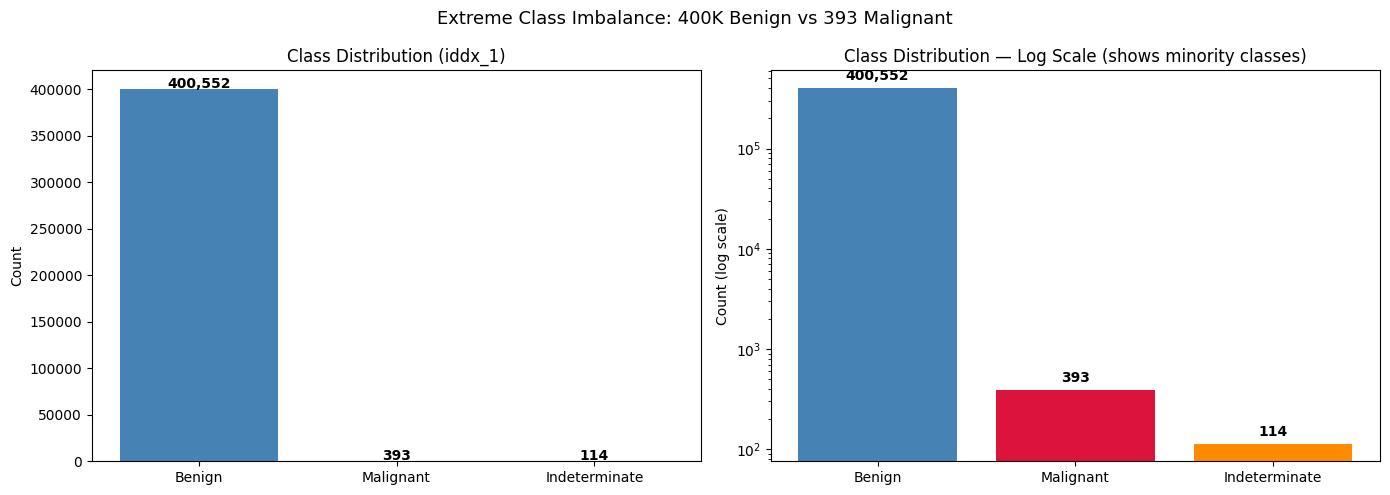

In [ ]:
# 1: iddx_1 class distribution (your classification target)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = train_df['iddx_1'].value_counts()
colors = ['steelblue', 'crimson', 'darkorange']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Class Distribution (iddx_1)')
axes[0].set_ylabel('Count')
for i, (val, cnt) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, cnt + 1000, f'{cnt:,}', ha='center', fontweight='bold')

# Log scale version — because 400K vs 393 is invisible otherwise
axes[1].bar(counts.index, counts.values, color=colors)
axes[1].set_yscale('log')
axes[1].set_title('Class Distribution — Log Scale (shows minority classes)')
axes[1].set_ylabel('Count (log scale)')
for i, (val, cnt) in enumerate(zip(counts.index, counts.values)):
    axes[1].text(i, cnt * 1.2, f'{cnt:,}', ha='center', fontweight='bold')

plt.suptitle('Extreme Class Imbalance: 400K Benign vs 393 Malignant', fontsize=13)
plt.tight_layout()
plt.show()

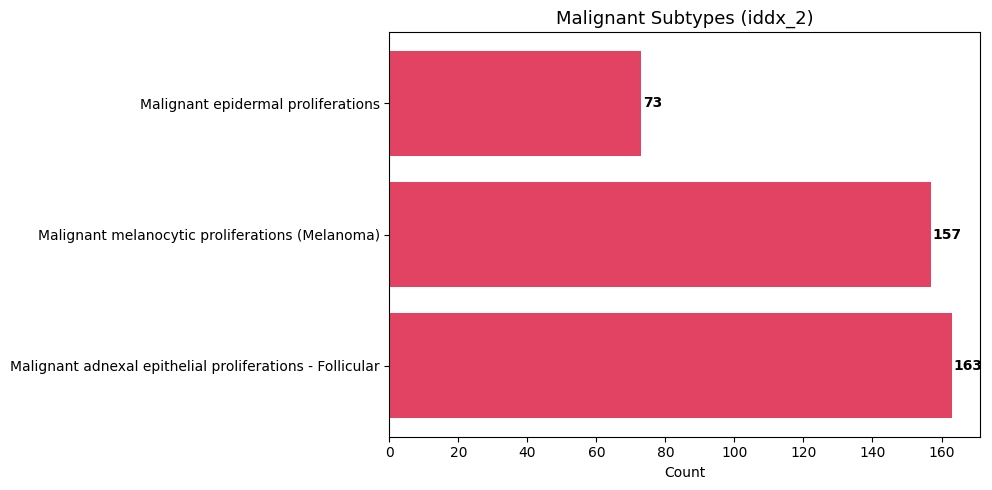

In [ ]:
#  2: Malignant subtypes breakdown (from iddx_full)
malignant_df = train_df[train_df['iddx_1'] == 'Malignant']

# Extract iddx_2 (cancer subtype)
subtype_counts = malignant_df['iddx_2'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(subtype_counts.index, subtype_counts.values, color='crimson', alpha=0.8)
ax.set_title('Malignant Subtypes (iddx_2)', fontsize=13)
ax.set_xlabel('Count')
for bar, val in zip(bars, subtype_counts.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
melanoma_rate = train_df['target'].mean()
print("Melanoma rate:", melanoma_rate)

Melanoma rate: 0.0009799056996601498


In [ ]:
train_df['patient_id'].nunique()

1042

In [ ]:
train_df.groupby('patient_id')['isic_id'].count().describe()

,isic_id
count,1042.000000
mean,384.893474
std,540.268913
min,1.000000
25%,115.000000
50%,241.500000
75%,477.500000
max,9184.000000


- The crosstab confirms that iddx_1 maps perfectly to target.
- Every Malignant = target 1, every Benign/Indeterminate = target 0. Critically, Indeterminate is coded as 0 (benign).
- This is a deliberate clinical decision as when uncertain, we don't flag as cancer.
- For our multiclass framing, we'll need to decide whether to keep Indeterminate as its own class or drop those 114 rows entirely (they're ambiguous by definition).

**EDA - Age**

=== Age Summary ===
count    398261.000000
mean         58.012986
std          13.596165
min           5.000000
25%          50.000000
50%          60.000000
75%          70.000000
max          85.000000
Name: age_approx, dtype: float64

Missing age: 2798


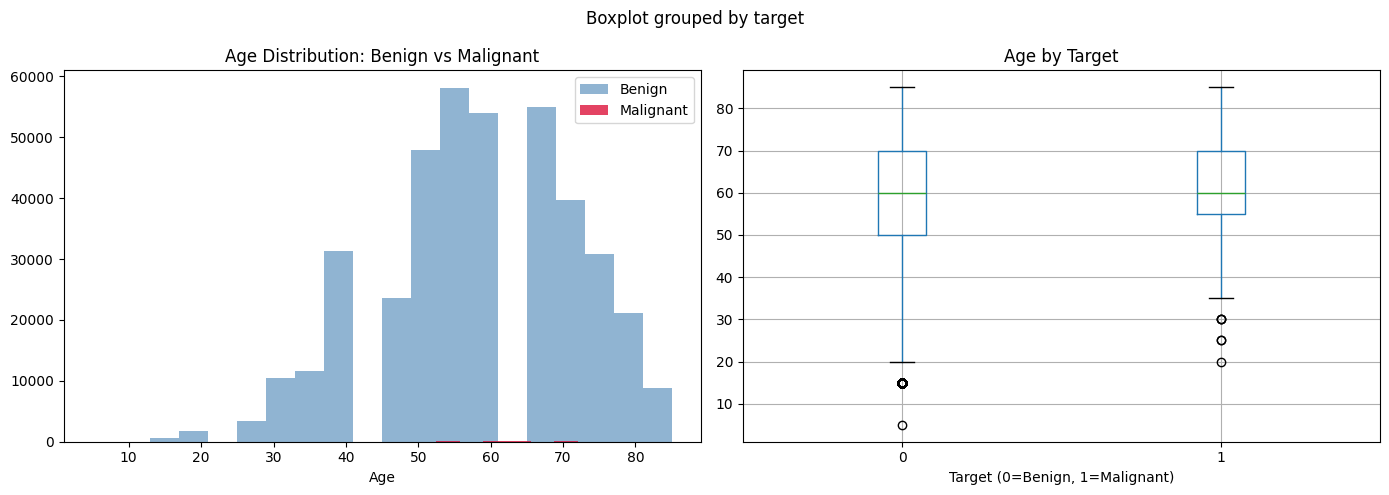


=== Age by diagnosis class ===
                  count       mean        std   min   25%   50%   75%   max
iddx_1                                                                     
Benign         397758.0  58.010637  13.597240   5.0  50.0  60.0  70.0  85.0
Indeterminate     113.0  54.690265  13.467606  25.0  45.0  55.0  65.0  85.0
Malignant         390.0  61.371795  11.932877  20.0  55.0  60.0  70.0  85.0


In [ ]:
# Age basics
print("=== Age Summary ===")
print(train_df['age_approx'].describe())
print("\nMissing age:", train_df['age_approx'].isnull().sum())

# Age distribution by target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_df[train_df['target']==0]['age_approx'].dropna(),
             bins=20, alpha=0.6, label='Benign', color='steelblue')
axes[0].hist(train_df[train_df['target']==1]['age_approx'].dropna(),
             bins=20, alpha=0.8, label='Malignant', color='crimson')
axes[0].set_title('Age Distribution: Benign vs Malignant')
axes[0].set_xlabel('Age')
axes[0].legend()

# Boxplot
train_df.boxplot(column='age_approx', by='target', ax=axes[1])
axes[1].set_title('Age by Target')
axes[1].set_xlabel('Target (0=Benign, 1=Malignant)')

plt.tight_layout()
plt.show()

# Age by iddx_1
print("\n=== Age by diagnosis class ===")
print(train_df.groupby('iddx_1')['age_approx'].describe())

- Malignant cases have a noticeably higher mean age (61.4) vs Benign (58.0) and Indeterminate (54.7).
- The boxplots look similar but malignancy is more concentrated in older patients.
- The min age of 20 for a malignant case is worth flagging (rare but real). Missing age is only 0.7% so it's safe to impute with median.

**Sex and Anotomical Site**

In [ ]:
print("=== Sex distribution ===")
print(train_df['sex'].value_counts())

print("\n=== Anatomical site ===")
print(train_df['anatom_site_general'].value_counts())

# Sex vs malignancy
print("\n=== Sex vs target ===")
print(pd.crosstab(train_df['sex'], train_df['target'], normalize='index').round(3))

# Anatomical site vs malignancy
print("\n=== Anatomical site vs target (malignancy rate) ===")
print(pd.crosstab(train_df['anatom_site_general'], train_df['target'], normalize='index').round(4).sort_values(1, ascending=False))

=== Sex distribution ===
sex
male      265546
female    123996
Name: count, dtype: int64

=== Anatomical site ===
anatom_site_general
posterior torso    121902
lower extremity    103028
anterior torso      87770
upper extremity     70557
head/neck           12046
Name: count, dtype: int64

=== Sex vs target ===
target      0      1
sex                 
female  0.999  0.001
male    0.999  0.001

=== Anatomical site vs target (malignancy rate) ===
target                    0       1
anatom_site_general                
head/neck            0.9935  0.0065
anterior torso       0.9991  0.0009
posterior torso      0.9992  0.0008
upper extremity      0.9992  0.0008
lower extremity      0.9993  0.0007


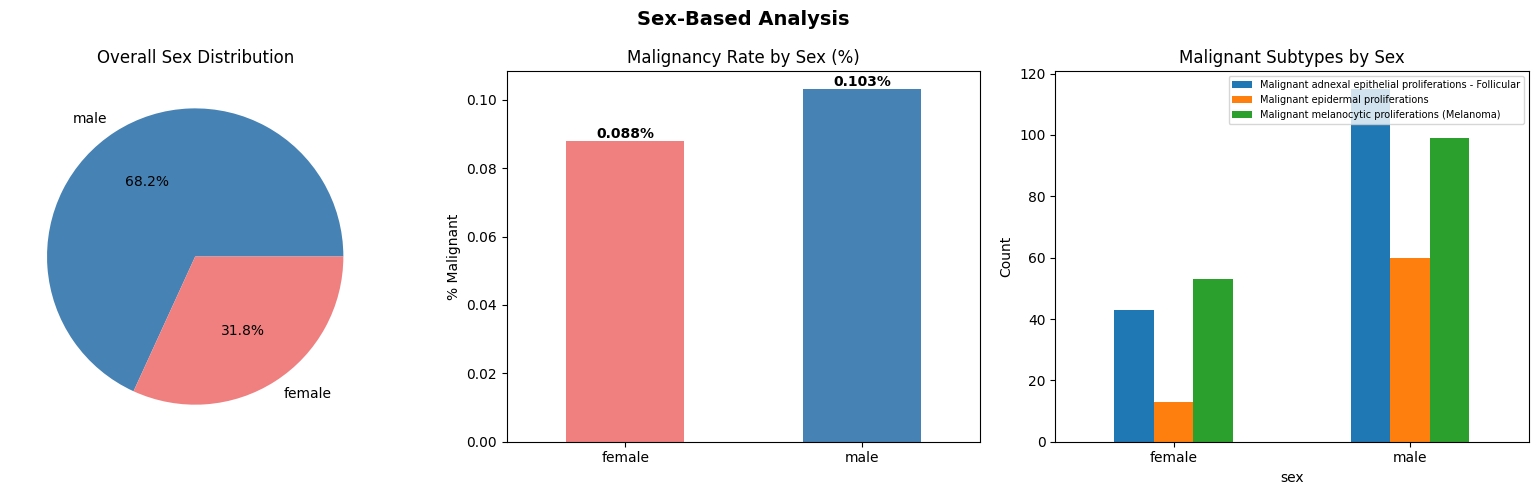

In [ ]:
# 3: Sex analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall sex distribution
sex_counts = train_df['sex'].value_counts()
axes[0].pie(sex_counts.values, labels=sex_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'lightcoral'])
axes[0].set_title('Overall Sex Distribution')

# Malignancy rate by sex
sex_mal = pd.crosstab(train_df['sex'], train_df['target'], normalize='index') * 100
sex_mal[1].plot(kind='bar', ax=axes[1], color=['lightcoral', 'steelblue'], rot=0)
axes[1].set_title('Malignancy Rate by Sex (%)')
axes[1].set_ylabel('% Malignant')
axes[1].set_xlabel('')
for i, v in enumerate(sex_mal[1]):
    axes[1].text(i, v + 0.001, f'{v:.3f}%', ha='center', fontweight='bold')

# Malignant subtypes by sex
mal_sex = malignant_df.groupby(['sex', 'iddx_2']).size().unstack(fill_value=0)
mal_sex.plot(kind='bar', ax=axes[2], rot=0)
axes[2].set_title('Malignant Subtypes by Sex')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=7, loc='upper right')

plt.suptitle('Sex-Based Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

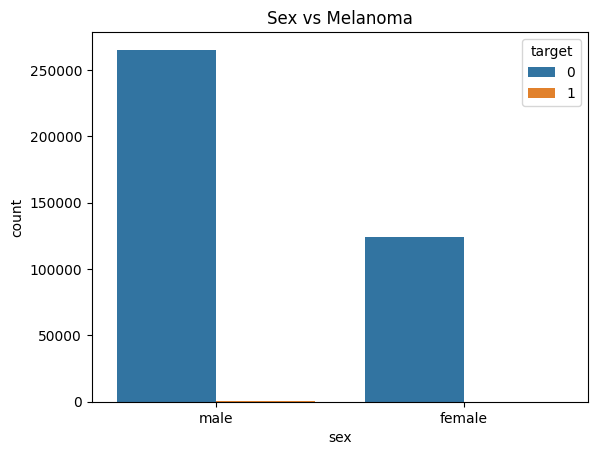

In [ ]:
sns.countplot(data=train_df, x='sex', hue='target')
plt.title("Sex vs Melanoma")
plt.show()

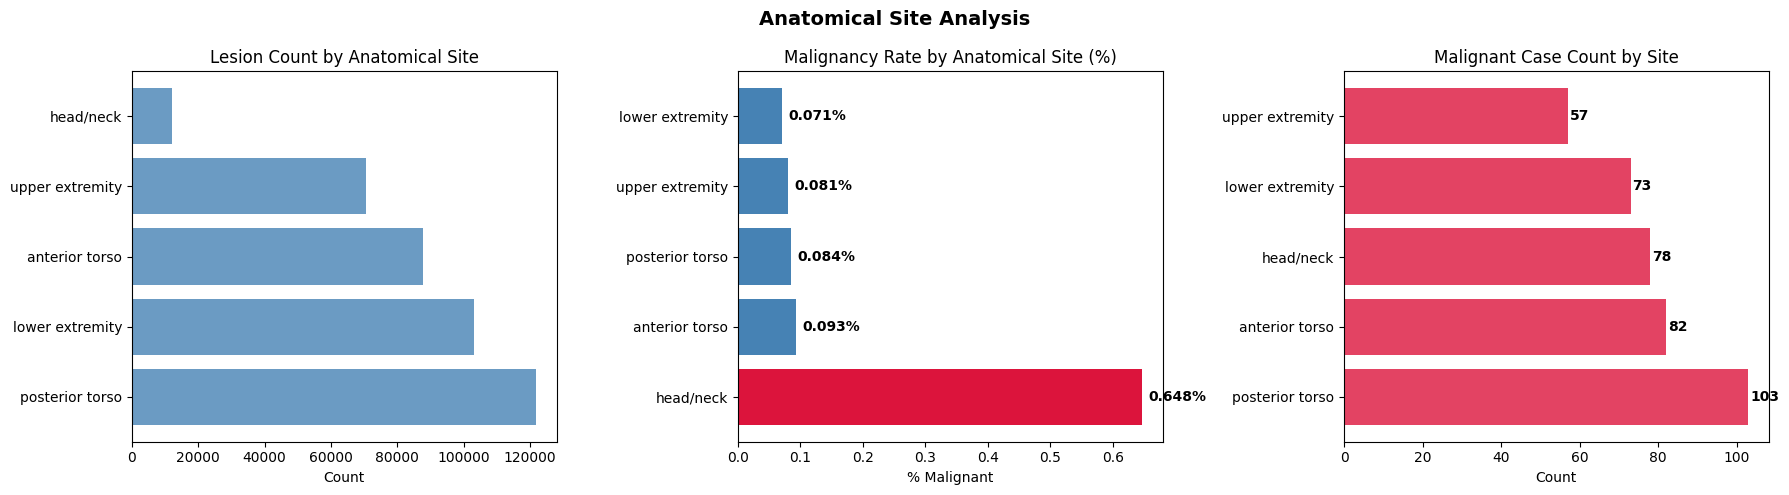

In [27]:
# 4: Anatomical site analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall site distribution
site_counts = train_df['anatom_site_general'].value_counts()
axes[0].barh(site_counts.index, site_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Lesion Count by Anatomical Site')
axes[0].set_xlabel('Count')

# Malignancy rate per site
site_mal = pd.crosstab(train_df['anatom_site_general'],
                        train_df['target'], normalize='index') * 100
site_mal_sorted = site_mal.sort_values(1, ascending=False)
colors_site = ['crimson' if v > 0.3 else 'steelblue' for v in site_mal_sorted[1]]
axes[1].barh(site_mal_sorted.index, site_mal_sorted[1], color=colors_site)
axes[1].set_title('Malignancy Rate by Anatomical Site (%)')
axes[1].set_xlabel('% Malignant')
for i, v in enumerate(site_mal_sorted[1]):
    axes[1].text(v + 0.01, i, f'{v:.3f}%', va='center', fontweight='bold')

# Malignant cases per site (absolute count)
mal_site = malignant_df['anatom_site_general'].value_counts()
axes[2].barh(mal_site.index, mal_site.values, color='crimson', alpha=0.8)
axes[2].set_title('Malignant Case Count by Site')
axes[2].set_xlabel('Count')
for i, v in enumerate(mal_site.values):
    axes[2].text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.suptitle('Anatomical Site Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

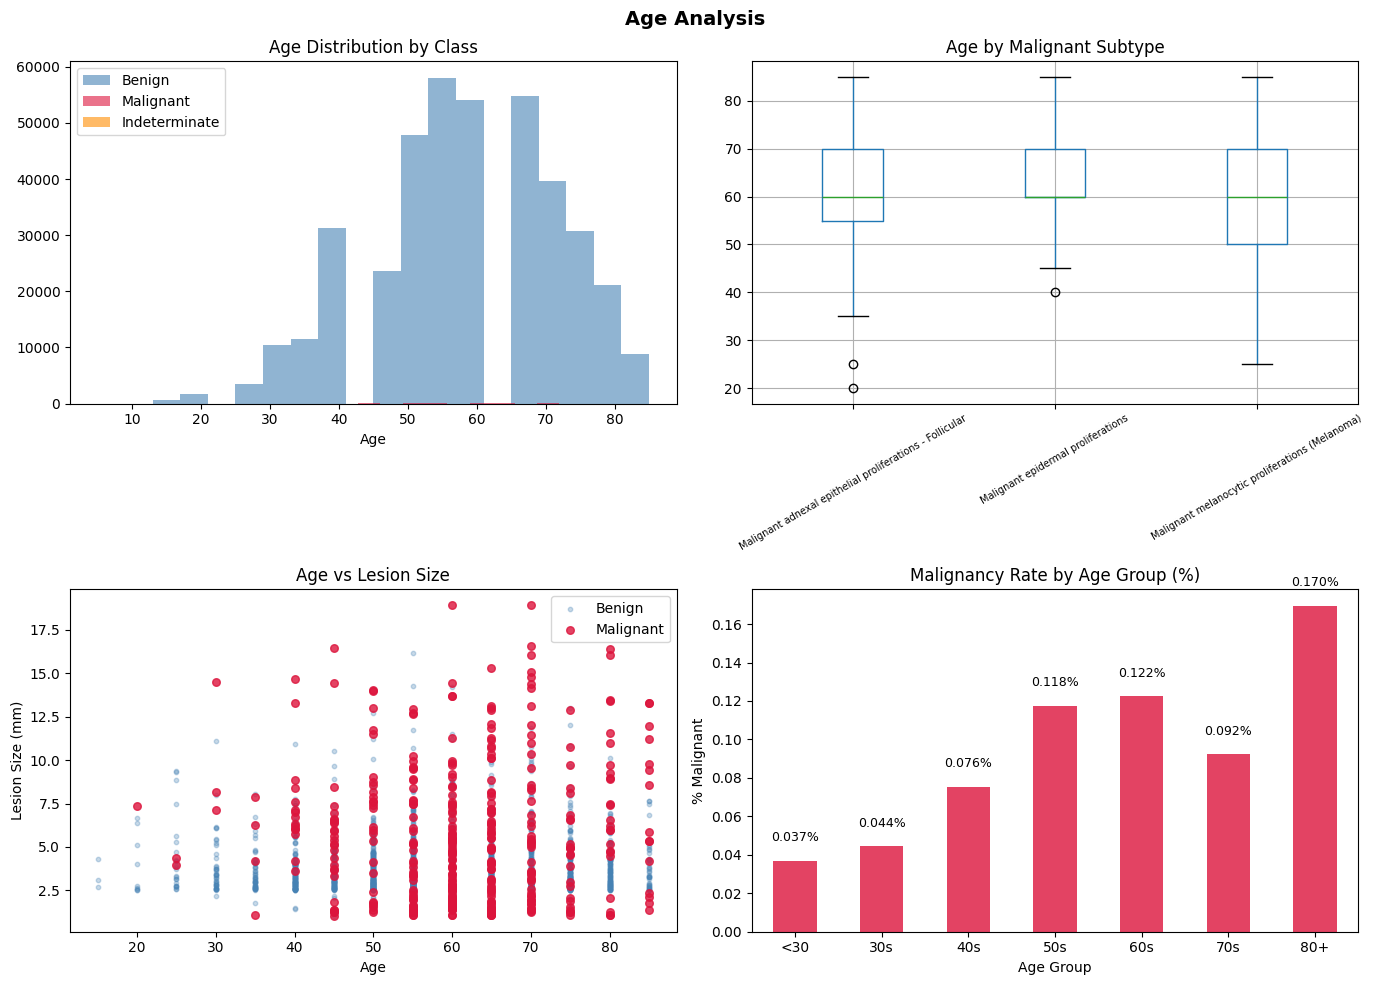

In [28]:
# 5: Age deep dive
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution by iddx_1 (all 3 classes)
for label, color in zip(['Benign', 'Malignant', 'Indeterminate'],
                         ['steelblue', 'crimson', 'darkorange']):
    subset = train_df[train_df['iddx_1'] == label]['age_approx'].dropna()
    axes[0][0].hist(subset, bins=20, alpha=0.6, label=label, color=color)
axes[0][0].set_title('Age Distribution by Class')
axes[0][0].set_xlabel('Age')
axes[0][0].legend()

# Age by malignant subtype
malignant_df.boxplot(column='age_approx', by='iddx_2', ax=axes[0][1])
axes[0][1].set_title('Age by Malignant Subtype')
axes[0][1].set_xlabel('')
axes[0][1].tick_params(axis='x', rotation=30)
plt.sca(axes[0][1])
plt.xticks(fontsize=7)

# Age vs lesion size, colored by target
scatter_ben = train_df[train_df['target']==0].sample(2000, random_state=42)
scatter_mal = train_df[train_df['target']==1]
axes[1][0].scatter(scatter_ben['age_approx'], scatter_ben['clin_size_long_diam_mm'],
                   alpha=0.3, s=10, color='steelblue', label='Benign')
axes[1][0].scatter(scatter_mal['age_approx'], scatter_mal['clin_size_long_diam_mm'],
                   alpha=0.8, s=30, color='crimson', label='Malignant')
axes[1][0].set_title('Age vs Lesion Size')
axes[1][0].set_xlabel('Age')
axes[1][0].set_ylabel('Lesion Size (mm)')
axes[1][0].legend()

# Malignancy rate by age bucket
train_df['age_bucket'] = pd.cut(train_df['age_approx'],
                                 bins=[0,30,40,50,60,70,80,100],
                                 labels=['<30','30s','40s','50s','60s','70s','80+'])
age_mal = pd.crosstab(train_df['age_bucket'], train_df['target'], normalize='index') * 100
age_mal[1].plot(kind='bar', ax=axes[1][1], color='crimson', alpha=0.8, rot=0)
axes[1][1].set_title('Malignancy Rate by Age Group (%)')
axes[1][1].set_ylabel('% Malignant')
axes[1][1].set_xlabel('Age Group')
for i, v in enumerate(age_mal[1]):
    axes[1][1].text(i, v + 0.01, f'{v:.3f}%', ha='center', fontsize=9)

plt.suptitle('Age Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

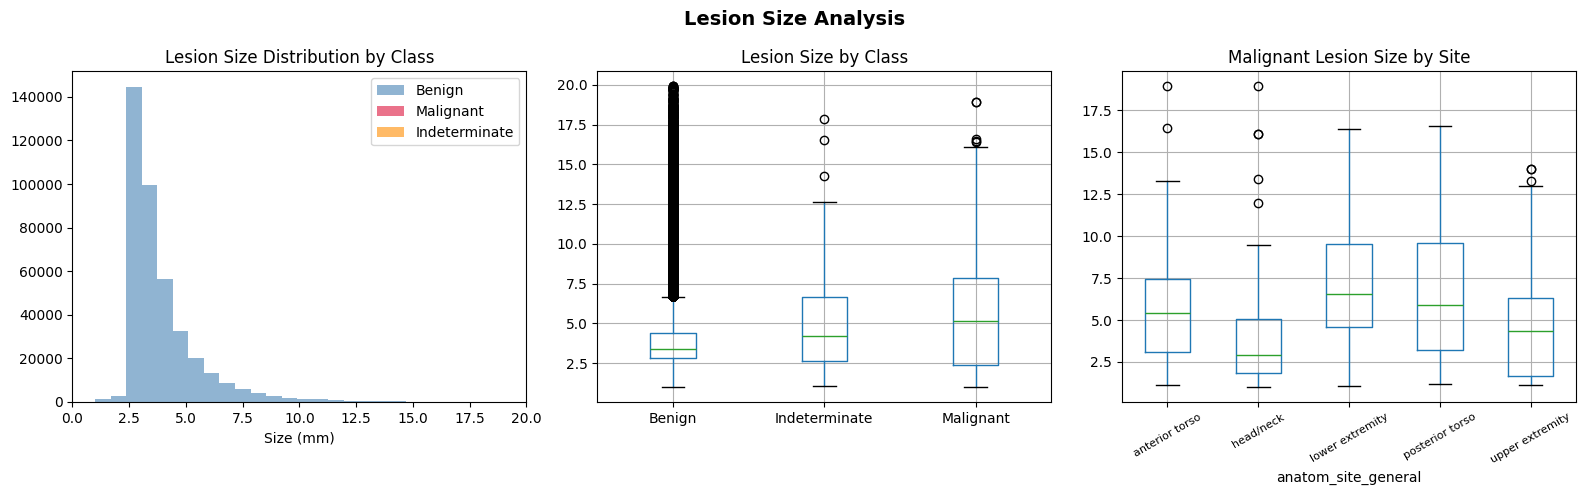

In [29]:
# 6: Lesion size analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution by class
for label, color in zip(['Benign', 'Malignant', 'Indeterminate'],
                         ['steelblue', 'crimson', 'darkorange']):
    subset = train_df[train_df['iddx_1'] == label]['clin_size_long_diam_mm'].dropna()
    axes[0].hist(subset, bins=40, alpha=0.6, label=label, color=color)
axes[0].set_title('Lesion Size Distribution by Class')
axes[0].set_xlabel('Size (mm)')
axes[0].set_xlim(0, 20)
axes[0].legend()

# Boxplot
train_df[train_df['clin_size_long_diam_mm'] < 20].boxplot(
    column='clin_size_long_diam_mm', by='iddx_1', ax=axes[1])
axes[1].set_title('Lesion Size by Class')
axes[1].set_xlabel('')

# Size by anatomical site (malignant only)
malignant_df.boxplot(column='clin_size_long_diam_mm', by='anatom_site_general', ax=axes[2])
axes[2].set_title('Malignant Lesion Size by Site')
axes[2].tick_params(axis='x', rotation=30)
plt.sca(axes[2])
plt.xticks(fontsize=8)

plt.suptitle('Lesion Size Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- Male/female malignancy rates are identical (both 0.001). The dataset is heavily male-skewed (265K male vs 124K female) but the rate of malignancy is the same.
- ead/neck has the highest malignancy rate (0.65%), nearly 8x higher than lower extremity (0.07%). This is clinically very expected as sun-exposed areas are higher risk.
- Malignant lesions are noticeably larger mean 5.75mm vs 3.93mm for benign.

**Image Exploration**

In [30]:
from PIL import Image
import os

img_dir = "train-image/image"
sample_img = os.listdir(img_dir)[3]
img = Image.open(os.path.join(img_dir, sample_img))

print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (133, 133)
Image mode: RGB


In [31]:
mel_ids = train_df[train_df['target']==1]['isic_id'].sample(5).values
ben_ids = train_df[train_df['target']==0]['isic_id'].sample(5).values

In [32]:
train_df.groupby('target')['clin_size_long_diam_mm'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,400666.0,3.929043,1.738712,1.00,2.84,3.37,4.38,28.40
1,393.0,5.749771,3.902299,1.01,2.40,5.14,7.87,18.94


In [33]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_dir = "train-image/image"

# Block 1: Basic image properties
sizes = []
for fname in os.listdir(img_dir)[:2000]:  # sample 2000 to keep it fast
    try:
        img = Image.open(os.path.join(img_dir, fname))
        sizes.append(img.size)
    except:
        pass

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
print("Unique sizes:", set(sizes[:50]))
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")

Unique sizes: {(139, 139), (107, 107), (125, 125), (103, 103), (135, 135), (121, 121), (131, 131), (117, 117), (145, 145), (173, 173), (141, 141), (127, 127), (113, 113), (91, 91), (123, 123), (151, 151), (137, 137), (133, 133), (143, 143), (129, 129), (115, 115), (161, 161), (157, 157), (111, 111)}
Width  — min: 67, max: 223, mean: 133.9
Height — min: 67, max: 223, mean: 133.9


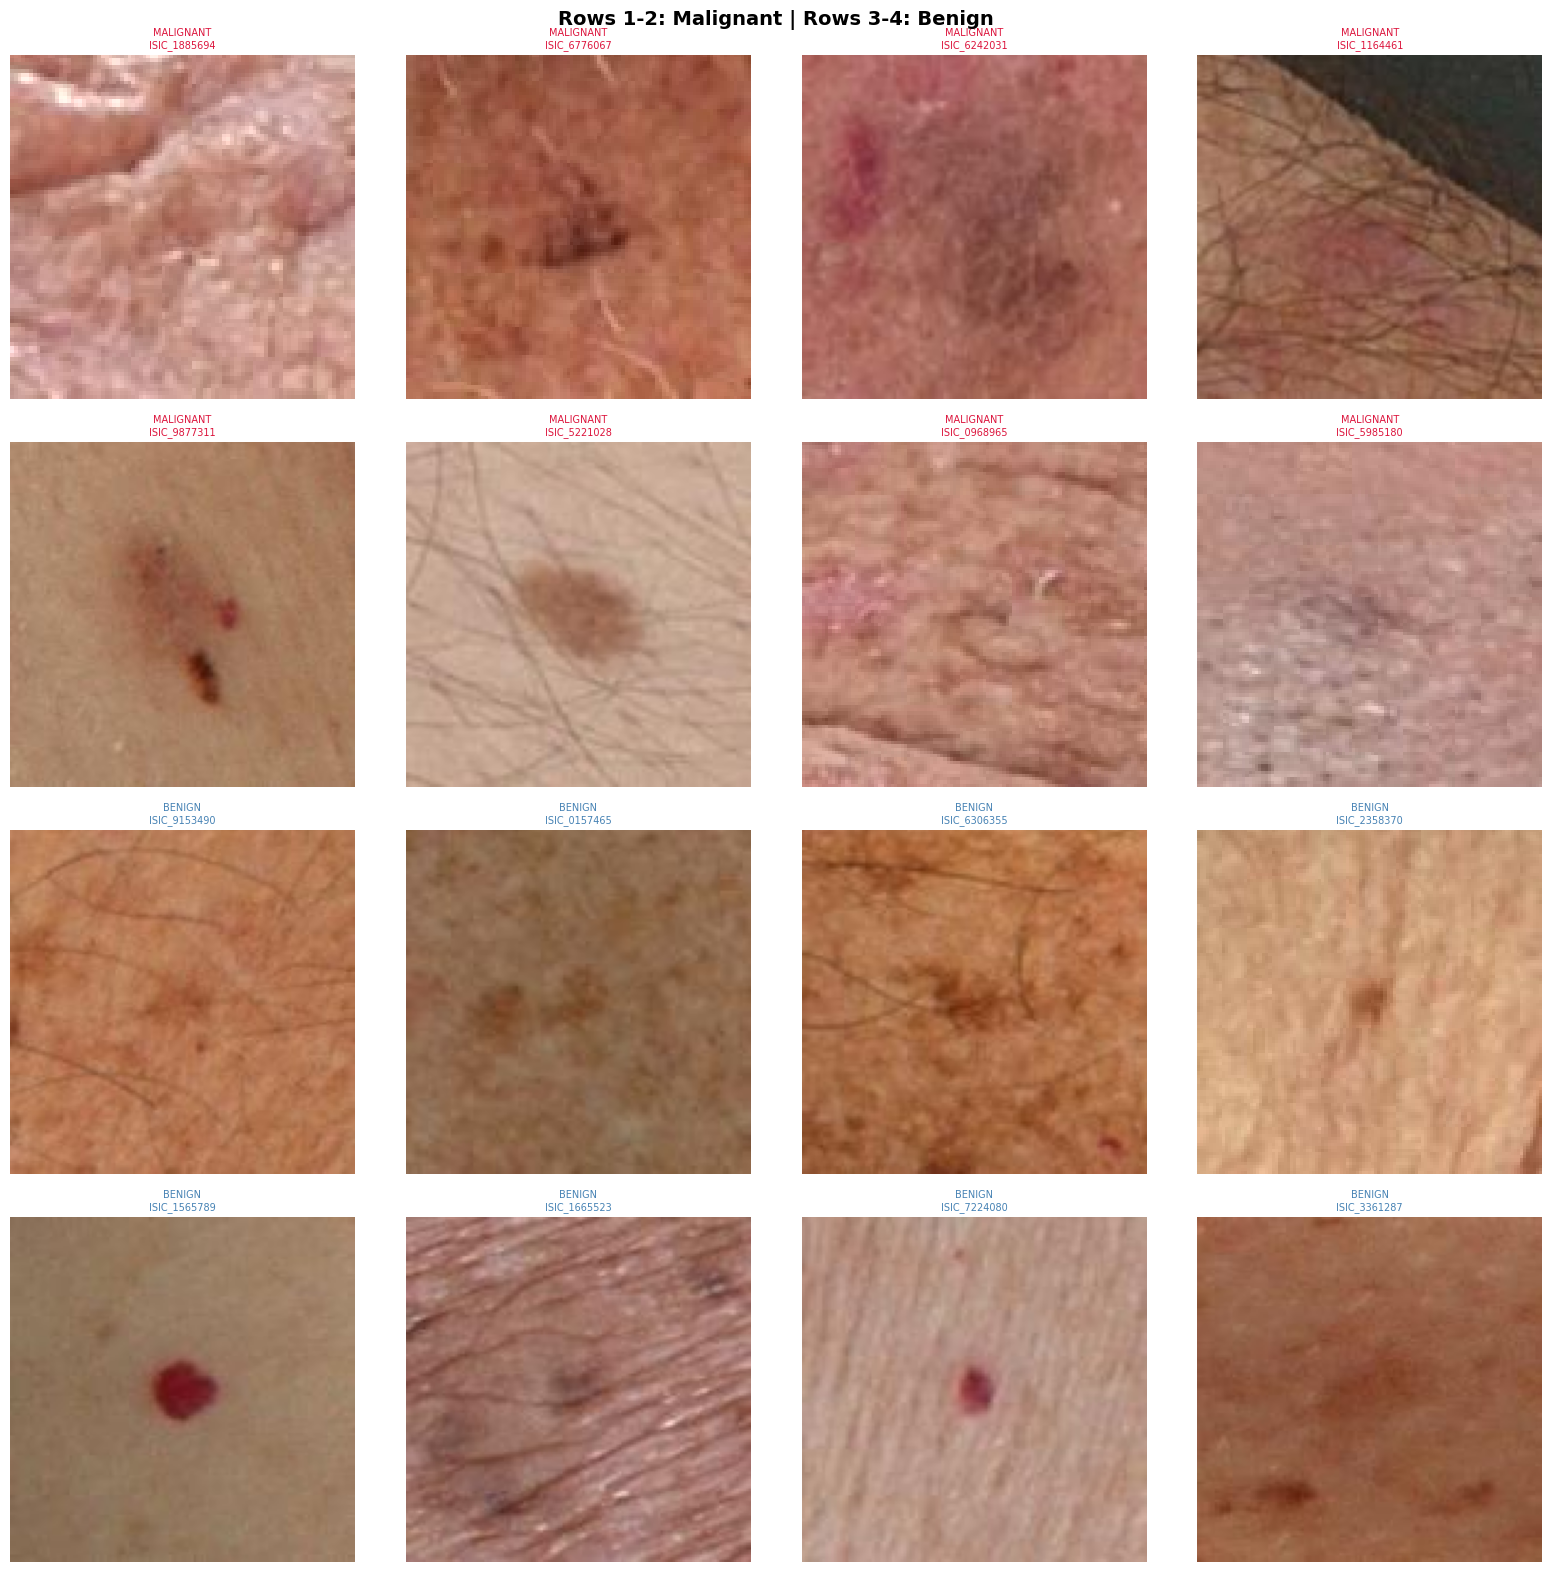

In [34]:
# Block 2: Visual sample — Benign vs Malignant
malignant_ids = train_df[train_df['target'] == 1]['isic_id'].sample(8, random_state=42).values
benign_ids    = train_df[train_df['target'] == 0]['isic_id'].sample(8, random_state=42).values

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Rows 1-2: Malignant | Rows 3-4: Benign', fontsize=14, fontweight='bold')

for i, isic_id in enumerate(malignant_ids):
    row, col = divmod(i, 4)
    img_path = os.path.join(img_dir, f"{isic_id}.jpg")
    img = Image.open(img_path)
    axes[row][col].imshow(img)
    axes[row][col].set_title(f'MALIGNANT\n{isic_id}', fontsize=7, color='crimson')
    axes[row][col].axis('off')

for i, isic_id in enumerate(benign_ids):
    row, col = divmod(i + 8, 4)
    img_path = os.path.join(img_dir, f"{isic_id}.jpg")
    img = Image.open(img_path)
    axes[row][col].imshow(img)
    axes[row][col].set_title(f'BENIGN\n{isic_id}', fontsize=7, color='steelblue')
    axes[row][col].axis('off')

plt.tight_layout()
plt.show()

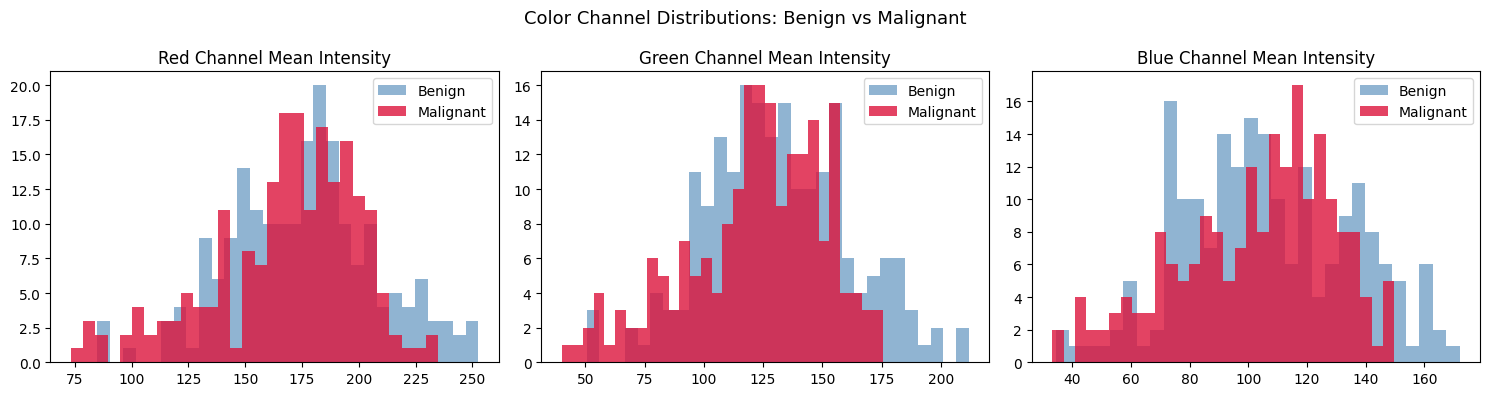

In [35]:
#  Block 3: Pixel intensity and color channel distributions
def get_channel_means(isic_id):
    img_path = os.path.join(img_dir, f"{isic_id}.jpg")
    img = np.array(Image.open(img_path).resize((64, 64)))
    return img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()

# Sample 200 from each class
mal_sample = train_df[train_df['target'] == 1]['isic_id'].sample(min(200, 393), random_state=42).values
ben_sample = train_df[train_df['target'] == 0]['isic_id'].sample(200, random_state=42).values

mal_channels = [get_channel_means(i) for i in mal_sample]
ben_channels = [get_channel_means(i) for i in ben_sample]

mal_r, mal_g, mal_b = zip(*mal_channels)
ben_r, ben_g, ben_b = zip(*ben_channels)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (m, b, ch) in zip(axes, [(mal_r, ben_r, 'Red'), (mal_g, ben_g, 'Green'), (mal_b, ben_b, 'Blue')]):
    ax.hist(b, bins=30, alpha=0.6, label='Benign', color='steelblue')
    ax.hist(m, bins=30, alpha=0.8, label='Malignant', color='crimson')
    ax.set_title(f'{ch} Channel Mean Intensity')
    ax.legend()

plt.suptitle('Color Channel Distributions: Benign vs Malignant', fontsize=13)
plt.tight_layout()
plt.show()

- Malignant lesions skew toward higher red channel intensity and lower blue channel intensity compared to benign. This makes clinical sense as malignant lesions often appear darker/redder due to increased vascularity and pigmentation irregularity. This is a weak but real signal.


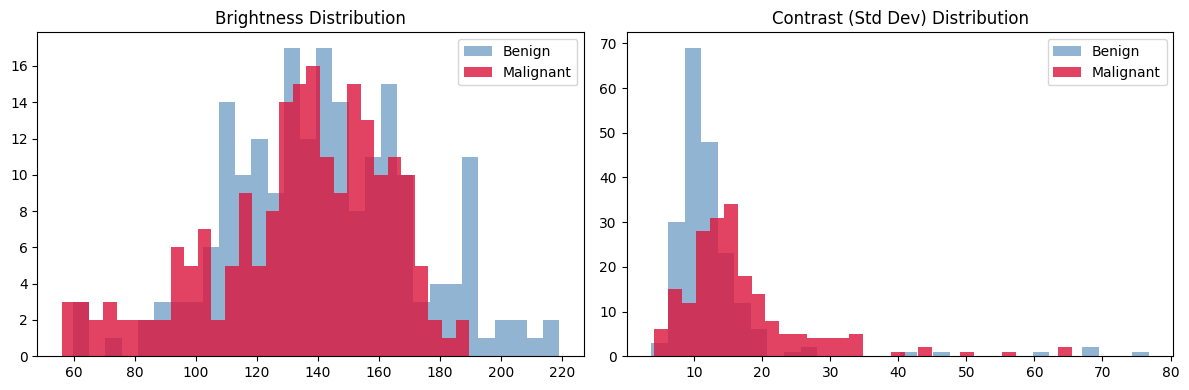

In [36]:
#  Block 4: Brightness and contrast variation
def get_brightness_contrast(isic_id):
    img = np.array(Image.open(os.path.join(img_dir, f"{isic_id}.jpg")).resize((64,64)).convert('L'))
    return img.mean(), img.std()

mal_stats = [get_brightness_contrast(i) for i in mal_sample]
ben_stats = [get_brightness_contrast(i) for i in ben_sample]

mal_bright, mal_contrast = zip(*mal_stats)
ben_bright, ben_contrast = zip(*ben_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ben_bright, bins=30, alpha=0.6, label='Benign', color='steelblue')
axes[0].hist(mal_bright, bins=30, alpha=0.8, label='Malignant', color='crimson')
axes[0].set_title('Brightness Distribution')
axes[0].legend()

axes[1].hist(ben_contrast, bins=30, alpha=0.6, label='Benign', color='steelblue')
axes[1].hist(mal_contrast, bins=30, alpha=0.8, label='Malignant', color='crimson')
axes[1].set_title('Contrast (Std Dev) Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

- Brightness: The distributions overlap heavily, meaning brightness alone won't separate classes. However malignant cases have a slightly wider spread. Some are very dark, some very bright, reflecting the visual heterogeneity that's actually a hallmark of malignancy (the "color variation" criterion in clinical ABCDE rules).

- Contrast: Benign lesions are tightly clustered at low contrast (std dev ~10-15), meaning they're visually uniform. Malignant lesions have a longer tail toward higher contrast  which is consistent with clinical knowledge that malignant lesions have irregular, uneven texture.

**Correlation**

Columns used: ['tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_L', 'tbp_lv_Lext', 'tbp_lv_areaMM2', 'tbp_lv_area_perim_ratio', 'tbp_lv_color_std_mean', 'tbp_lv_deltaA', 'tbp_lv_deltaB', 'tbp_lv_deltaL', 'tbp_lv_deltaLB', 'tbp_lv_deltaLBnorm', 'tbp_lv_eccentricity', 'tbp_lv_minorAxisMM', 'tbp_lv_nevi_confidence', 'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_perimeterMM', 'tbp_lv_radial_color_std_max', 'tbp_lv_stdL', 'tbp_lv_stdLExt', 'tbp_lv_symm_2axis', 'tbp_lv_symm_2axis_angle', 'tbp_lv_x', 'tbp_lv_y', 'tbp_lv_z', 'tbp_lv_dnn_lesion_confidence', 'age_approx', 'clin_size_long_diam_mm', 'target']


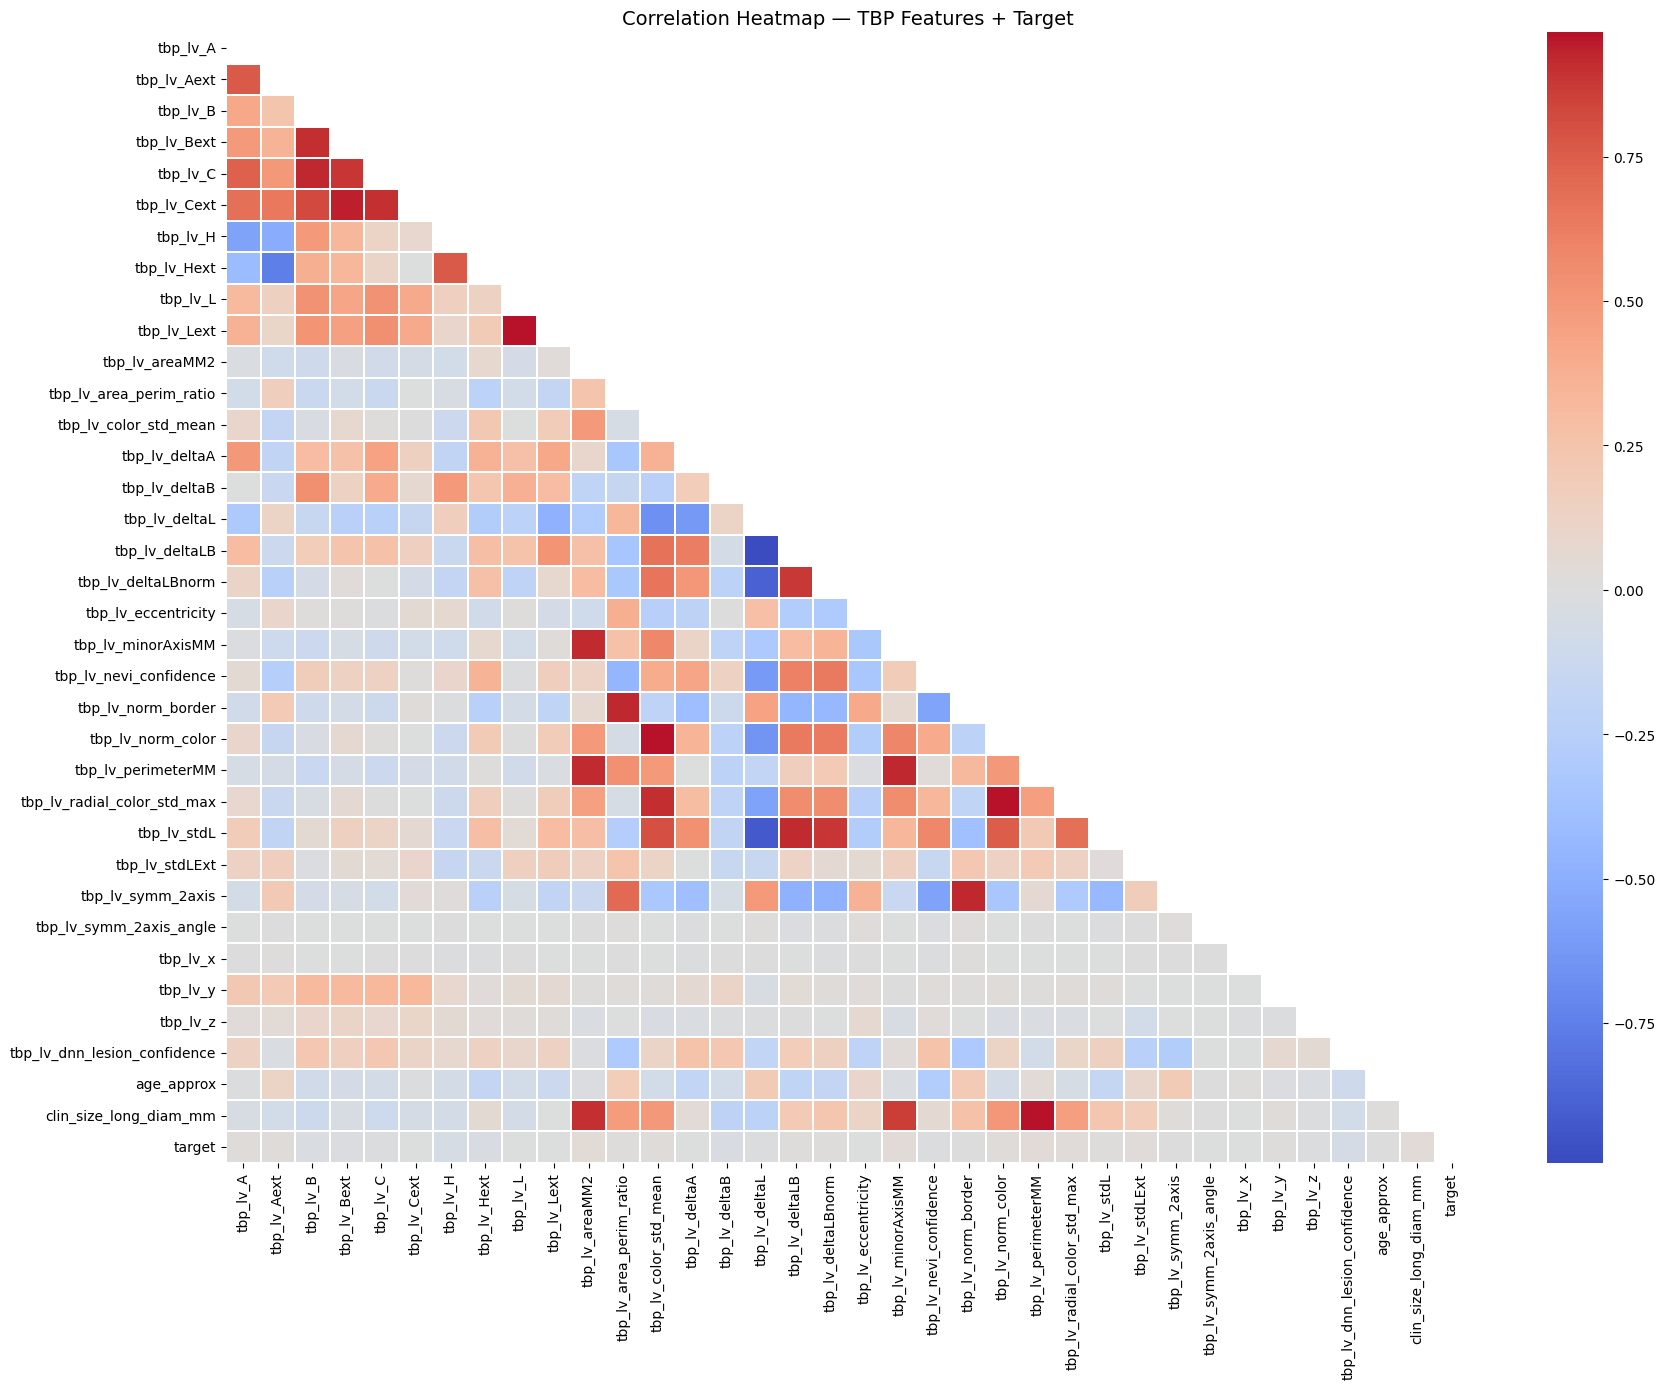


=== Top features correlated with target ===
tbp_lv_dnn_lesion_confidence    0.054766
tbp_lv_areaMM2                  0.045139
tbp_lv_H                        0.044884
tbp_lv_perimeterMM              0.036188
tbp_lv_minorAxisMM              0.035757
tbp_lv_deltaB                   0.035069
clin_size_long_diam_mm          0.032682
tbp_lv_Hext                     0.032671
tbp_lv_B                        0.026366
tbp_lv_stdLExt                  0.026084
tbp_lv_radial_color_std_max     0.025441
tbp_lv_color_std_mean           0.024271
tbp_lv_Aext                     0.023206
tbp_lv_norm_color               0.022264
tbp_lv_A                        0.019788
Name: target, dtype: float64


In [37]:
# Correlation heatmap of numeric TBP features
tbp_cols = [col for col in train_df.columns if col.startswith('tbp_lv')]
tbp_cols += ['age_approx', 'clin_size_long_diam_mm', 'target']

# Keep only numeric columns (drops tbp_lv_location, tbp_lv_location_simple)
tbp_numeric = train_df[tbp_cols].select_dtypes(include=[np.number])

print("Columns used:", tbp_numeric.columns.tolist())

corr = tbp_numeric.corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — TBP Features + Target', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with target
print("\n=== Top features correlated with target ===")
print(corr['target'].drop('target').abs().sort_values(ascending=False).head(15))

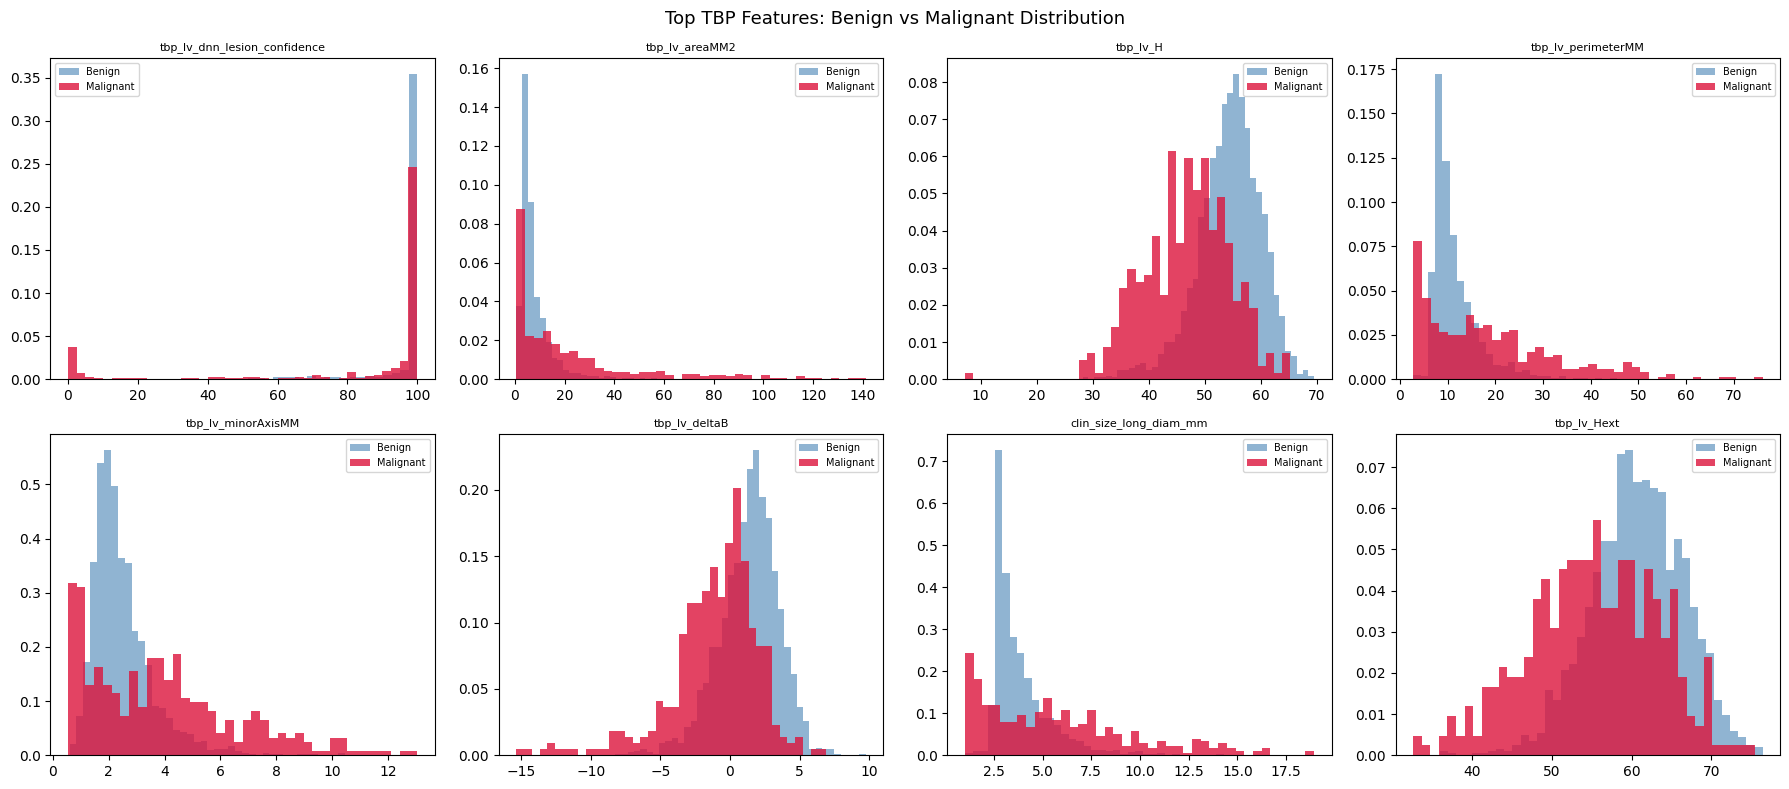

In [38]:
#  TBP features: distribution for malignant vs benign
# Focus on features most correlated with target

top_features = corr['target'].drop('target').abs().sort_values(ascending=False).head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ben = train_df[train_df['target']==0][feat].dropna()
    mal = train_df[train_df['target']==1][feat].dropna()
    axes[i].hist(ben.sample(min(2000, len(ben)), random_state=42),
                 bins=40, alpha=0.6, color='steelblue', label='Benign', density=True)
    axes[i].hist(mal, bins=40, alpha=0.8, color='crimson', label='Malignant', density=True)
    axes[i].set_title(feat, fontsize=8)
    axes[i].legend(fontsize=7)

plt.suptitle('Top TBP Features: Benign vs Malignant Distribution', fontsize=13)
plt.tight_layout()
plt.show()

=== Lesions per patient ===
count    1042.000000
mean      384.893474
std       540.268913
min         1.000000
25%       115.000000
50%       241.500000
75%       477.500000
max      9184.000000
Name: total_lesions, dtype: float64

Patients with at least 1 malignant lesion: 259
Total patients: 1042


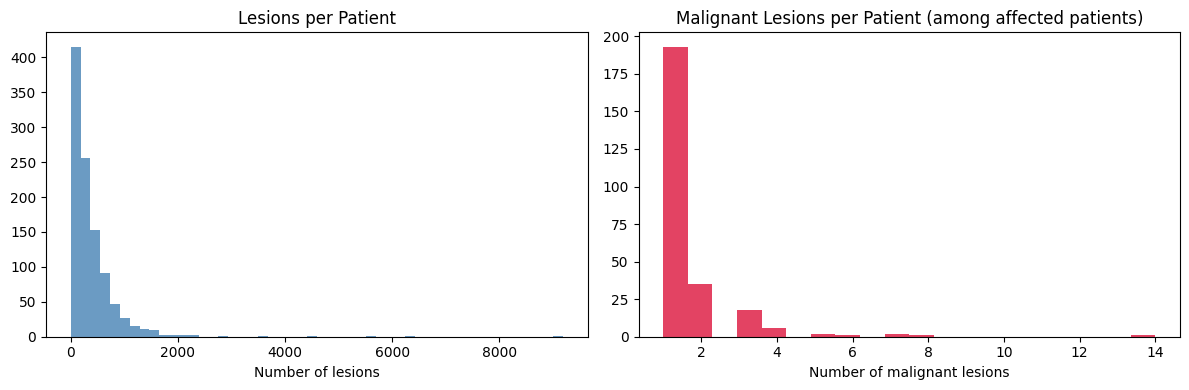

In [39]:
#  Patient-level analysis: how many lesions per patient?
patient_counts = train_df.groupby('patient_id').agg(
    total_lesions=('isic_id', 'count'),
    malignant_lesions=('target', 'sum')
).reset_index()

print("=== Lesions per patient ===")
print(patient_counts['total_lesions'].describe())
print("\nPatients with at least 1 malignant lesion:", (patient_counts['malignant_lesions'] > 0).sum())
print("Total patients:", len(patient_counts))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(patient_counts['total_lesions'], bins=50, color='steelblue', alpha=0.8)
axes[0].set_title('Lesions per Patient')
axes[0].set_xlabel('Number of lesions')

axes[1].hist(patient_counts[patient_counts['malignant_lesions'] > 0]['malignant_lesions'],
             bins=20, color='crimson', alpha=0.8)
axes[1].set_title('Malignant Lesions per Patient (among affected patients)')
axes[1].set_xlabel('Number of malignant lesions')

plt.tight_layout()
plt.show()

**Interpretation**

- Can merge "Intermediate" into Benign and do 2 class classification.
- Models :Image Based CNN or Ensemble (Take predictions (or embeddings) from the CNN + tabular features → feed into a lightweight classifier)

# **Modelling**

**Two Types of Data Available:**
- Tabular: the 22 features we selected earlier from the CSV
- Image: the actual 119x119 pixel lesion photos


**Setup**

In [40]:
# SETUP

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (roc_auc_score, classification_report,
                              roc_curve, auc, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from xgboost import XGBClassifier
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import EfficientNet_B0_Weights
from sklearn.preprocessing import StandardScaler
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import warnings
warnings.filterwarnings('ignore')

#  Label encoding
train_df['label'] = train_df['iddx_1'].map({
    'Benign': 0, 'Indeterminate': 0, 'Malignant': 1
})

features_to_use = [
    'age_approx', 'clin_size_long_diam_mm', 'tbp_lv_areaMM2',
    'tbp_lv_perimeterMM', 'tbp_lv_minorAxisMM', 'tbp_lv_deltaA',
    'tbp_lv_deltaB', 'tbp_lv_deltaL', 'tbp_lv_deltaLBnorm',
    'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_color_std_mean',
    'tbp_lv_radial_color_std_max', 'tbp_lv_norm_color', 'tbp_lv_stdL',
    'tbp_lv_stdLExt', 'tbp_lv_area_perim_ratio', 'tbp_lv_eccentricity',
    'tbp_lv_symm_2axis', 'tbp_lv_norm_border',
    'tbp_lv_dnn_lesion_confidence', 'tbp_lv_nevi_confidence',
]

df_model = train_df[features_to_use + ['label', 'patient_id',
                                        'sex', 'anatom_site_general',
                                        'isic_id']].copy()
df_model['sex'] = LabelEncoder().fit_transform(df_model['sex'].fillna('unknown'))
df_model['anatom_site_general'] = LabelEncoder().fit_transform(
    df_model['anatom_site_general'].fillna('unknown'))

all_features = features_to_use + ['sex', 'anatom_site_general']
df_model = df_model.dropna(subset=all_features + ['label'])

X      = df_model[all_features]
y      = df_model['label']
groups = df_model['patient_id']

#  Three-way patient-aware split: 70% train / 15% val / 15% test
# Step 1: split off 70% train, 30% temp
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups))

X_temp      = X.iloc[temp_idx]
y_temp      = y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

# Step 2: split temp into 50/50 → gives 15% val, 15% test overall
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx_rel, test_idx_rel = next(gss2.split(X_temp, y_temp, groups_temp))

val_idx  = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

X_train = X.iloc[train_idx];  y_train = y.iloc[train_idx]
X_val   = X.iloc[val_idx];    y_val   = y.iloc[val_idx]
X_test  = X.iloc[test_idx];   y_test  = y.iloc[test_idx]

train_data = df_model.iloc[train_idx].copy()
val_data   = df_model.iloc[val_idx].copy()
test_data  = df_model.iloc[test_idx].copy()

print("═"*45)
print("         DATA SPLIT SUMMARY")
print("═"*45)
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:6}: {len(y_split):>7,} rows | "
          f"Malignant: {y_split.sum():>3} ({y_split.mean()*100:.3f}%)")
print("═"*45)

═════════════════════════════════════════════
         DATA SPLIT SUMMARY
═════════════════════════════════════════════
Train : 277,189 rows | Malignant: 302 (0.109%)
Val   :  60,388 rows | Malignant:  44 (0.073%)
Test  :  60,684 rows | Malignant:  44 (0.073%)
═════════════════════════════════════════════


In [41]:
# Shared Evaluation Function — used by all three models

def full_evaluation(y_true, y_prob, model_name, color='crimson',
                    cnn_fpr=None, cnn_tpr=None):
    """
    Produces all evaluation plots and prints for one model.
    Pass cnn_fpr/cnn_tpr to overlay CNN-only curve on combined model plot.
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    #  ROC
    fpr, tpr, roc_thresh = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    #  PR curve
    prec, rec, pr_thresh = precision_recall_curve(y_true, y_prob)

    #  Find threshold at 90% malignant recall
    valid = np.where(rec[:-1] >= 0.90)[0]
    if len(valid) > 0:
        opt_idx   = valid[-1]
        opt_thresh = pr_thresh[opt_idx]
    else:
        opt_thresh = 0.5

    # Predictions at two thresholds
    y_pred_05  = (y_prob >= 0.5).astype(int)
    y_pred_opt = (y_prob >= opt_thresh).astype(int)

    cm_05  = confusion_matrix(y_true, y_pred_05)
    cm_opt = confusion_matrix(y_true, y_pred_opt)

    tn1,fp1,fn1,tp1 = cm_05.ravel()
    tn2,fp2,fn2,tp2 = cm_opt.ravel()

    #  Figure layout
    fig = plt.figure(figsize=(20, 10))
    fig.suptitle(f'{model_name} — Full Evaluation (Test Set)',
                 fontsize=15, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # Plot 1: ROC curve
    ax1 = fig.add_subplot(gs[0, 0])
    if cnn_fpr is not None:
        ax1.plot(cnn_fpr, cnn_tpr, color='steelblue', lw=1.5,
                 linestyle='--', label=f'CNN only (AUC={cnn_auc:.3f})', alpha=0.7)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC={roc_auc:.4f})')
    ax1.plot([0,1],[0,1],'k--', alpha=0.4, label='Random (0.5)')
    ax1.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

    # Plot 2: Precision-Recall curve
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(rec, prec, color=color, lw=2)
    ax2.axvline(x=0.90, color='green', linestyle='--', alpha=0.7,
                label='90% recall target')
    ax2.set_xlabel('Recall (Malignant)'); ax2.set_ylabel('Precision (Malignant)')
    ax2.set_title('Precision-Recall Curve'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    # Plot 3: Recall vs False Positive count
    thresh_range = np.linspace(0.01, 0.99, 200)
    fp_counts, rec_vals = [], []
    for t in thresh_range:
        yp = (y_prob >= t).astype(int)
        cm_t = confusion_matrix(y_true, yp)
        tn_t,fp_t,fn_t,tp_t = cm_t.ravel()
        fp_counts.append(fp_t)
        rec_vals.append(tp_t/(tp_t+fn_t) if (tp_t+fn_t)>0 else 0)

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(fp_counts, rec_vals, color=color, lw=2)
    ax3.axhline(y=0.90, color='green',  linestyle='--', alpha=0.7, label='90% recall')
    ax3.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95% recall')
    ax3.set_xlabel('False Positives (benign wrongly flagged)')
    ax3.set_ylabel('Malignant Recall')
    ax3.set_title('Clinical Tradeoff:\nRecall vs False Alarms')
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

    # Plot 4: Confusion matrix at threshold 0.5
    ax4 = fig.add_subplot(gs[1, 0])
    ConfusionMatrixDisplay(cm_05, display_labels=['Benign','Malignant']).plot(
        ax=ax4, cmap='Blues', colorbar=False)
    ax4.set_title(f'Confusion Matrix\nThreshold=0.5 | Recall={tp1/(tp1+fn1):.3f}')

    # Plot 5: Confusion matrix at optimal threshold
    ax5 = fig.add_subplot(gs[1, 1])
    ConfusionMatrixDisplay(cm_opt, display_labels=['Benign','Malignant']).plot(
        ax=ax5, cmap='Blues', colorbar=False)
    ax5.set_title(f'Confusion Matrix\nThreshold={opt_thresh:.2f} | Recall={tp2/(tp2+fn2):.3f}')

    # Plot 6: Summary stats text box
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')
    summary = (
        f"{'═'*32}\n"
        f"  {model_name} RESULTS\n"
        f"{'═'*32}\n"
        f"  AUC:              {roc_auc:.4f}\n\n"
        f"  At threshold 0.5:\n"
        f"  • Malignant Recall: {tp1/(tp1+fn1):.4f}\n"
        f"  • True Positives:   {tp1}\n"
        f"  • False Negatives:  {fn1}\n"
        f"  • False Positives:  {fp1:,}\n\n"
        f"  At threshold {opt_thresh:.2f} (90% recall):\n"
        f"  • Malignant Recall: {tp2/(tp2+fn2):.4f}\n"
        f"  • True Positives:   {tp2}\n"
        f"  • False Negatives:  {fn2}\n"
        f"  • False Positives:  {fp2:,}\n"
        f"{'═'*32}"
    )
    ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # Print classification report
    print(f"\n=== {model_name} — Classification Report (threshold=0.5) ===")
    print(classification_report(y_true, y_pred_05,
                                  target_names=['Benign','Malignant']))

    return roc_auc, fpr, tpr

## 2. Model 1: XGBoost: Tabular Baseline

Class weight ratio: 916.8:1
[0]	validation_0-auc:0.84884
[50]	validation_0-auc:0.93035
[100]	validation_0-auc:0.91236
[150]	validation_0-auc:0.90310
[200]	validation_0-auc:0.89850
[250]	validation_0-auc:0.89698
[300]	validation_0-auc:0.89571
[350]	validation_0-auc:0.89362
[400]	validation_0-auc:0.88398
[450]	validation_0-auc:0.87954
[499]	validation_0-auc:0.87753


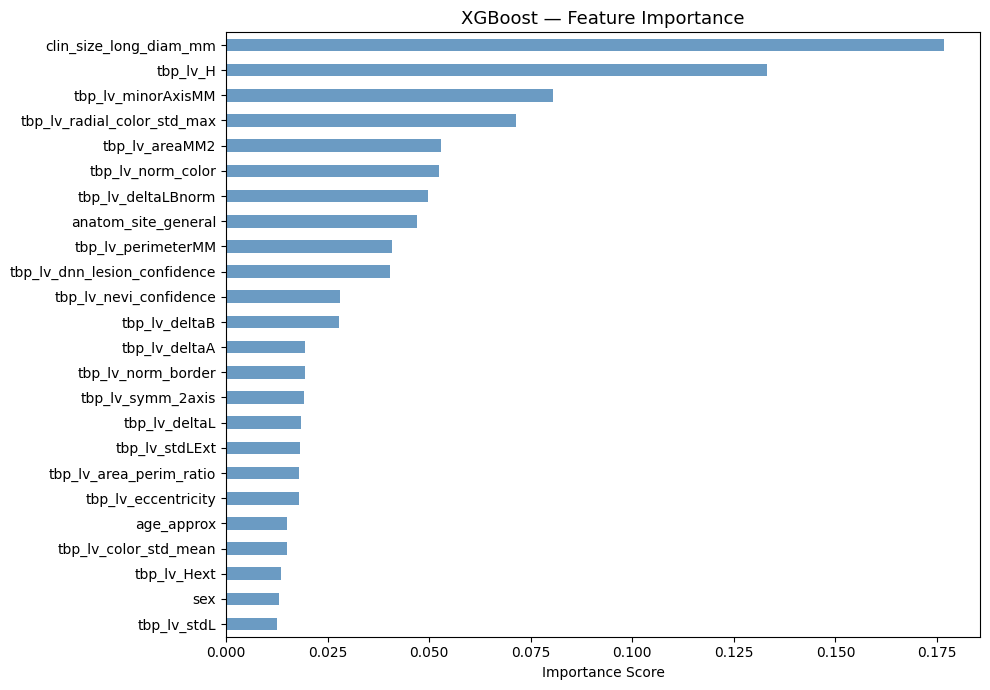

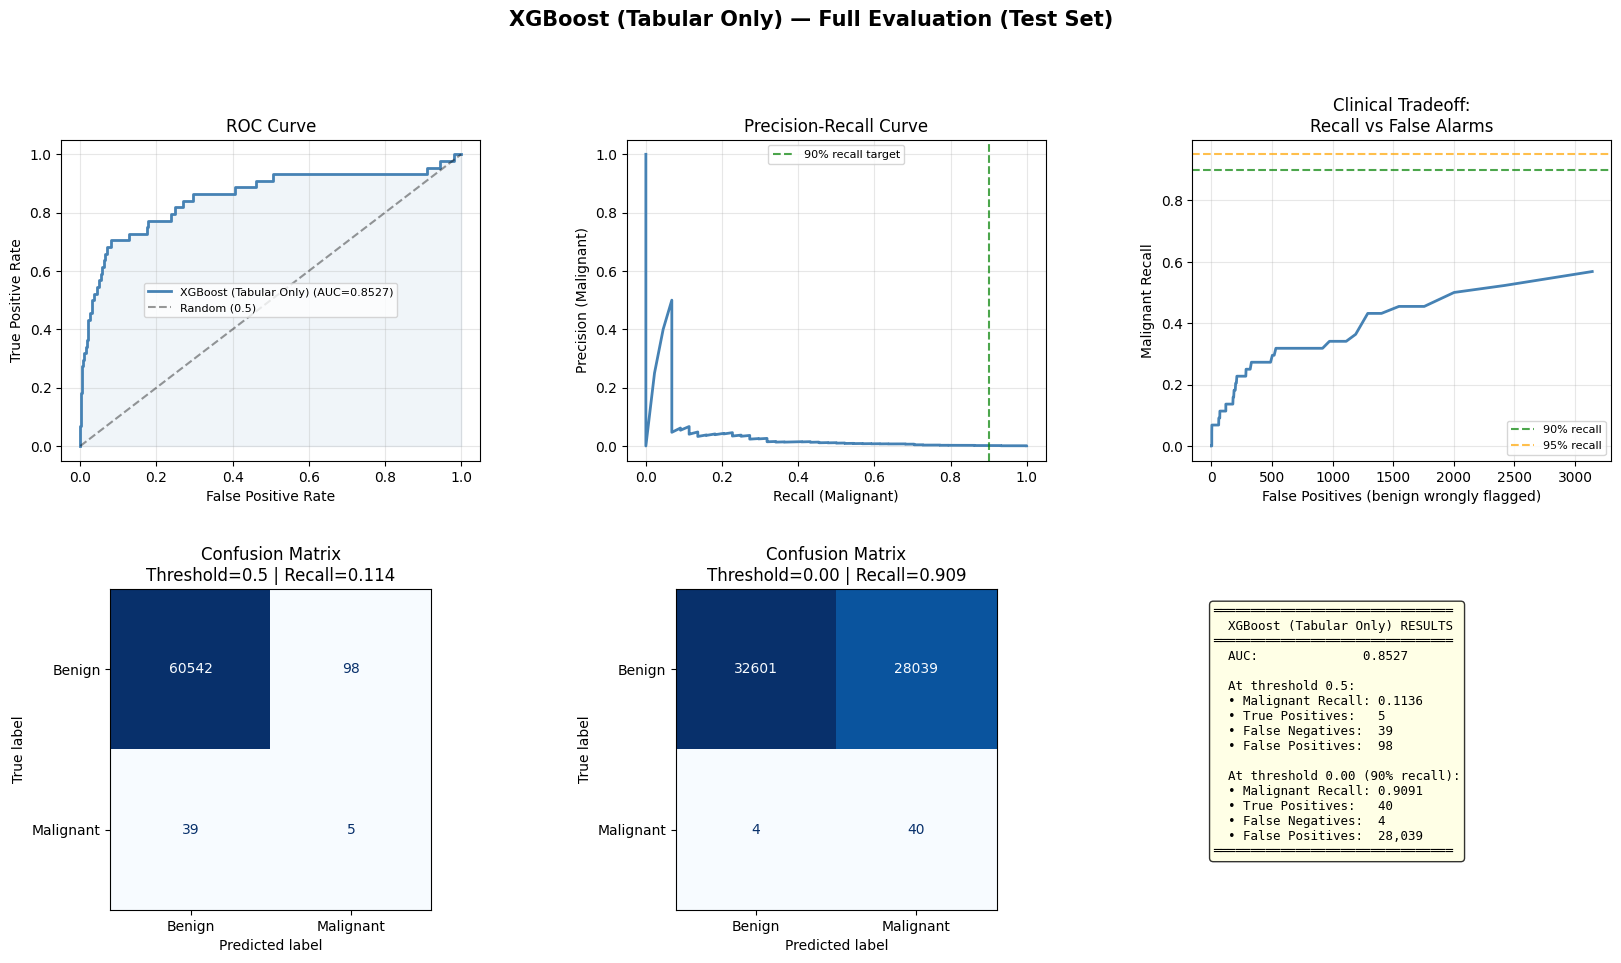


=== XGBoost (Tabular Only) — Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     60640
   Malignant       0.05      0.11      0.07        44

    accuracy                           1.00     60684
   macro avg       0.52      0.56      0.53     60684
weighted avg       1.00      1.00      1.00     60684



In [42]:
# MODEL 1: XGBOOST ON TABULAR FEATURES

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

scale = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Class weight ratio: {scale:.1f}:1")

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train_sc, y_train,
        eval_set=[(X_val_sc, y_val)],
        verbose=50)

#  Feature importance
feat_imp = pd.Series(xgb.feature_importances_, index=all_features)
fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('XGBoost — Feature Importance', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

#  Evaluate on TEST set
y_prob_xgb = xgb.predict_proba(X_test_sc)[:, 1]
xgb_auc, xgb_fpr, xgb_tpr = full_evaluation(
    y_test, y_prob_xgb,
    model_name='XGBoost (Tabular Only)',
    color='steelblue'
)

## 3. Model 2: EfficientNet-B0: Image Only CNN


Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 174MB/s]



=== CNN Phase 1: Frozen backbone ===
Epoch 1/5 | Train Loss: 1.9954 | Val Loss: 1.5894 | Val AUC: 0.8631
Epoch 2/5 | Train Loss: 1.7397 | Val Loss: 1.5004 | Val AUC: 0.8816
Epoch 3/5 | Train Loss: 1.6709 | Val Loss: 1.5398 | Val AUC: 0.8847
Epoch 4/5 | Train Loss: 1.6583 | Val Loss: 1.6697 | Val AUC: 0.8905
Epoch 5/5 | Train Loss: 1.6417 | Val Loss: 1.6836 | Val AUC: 0.8820

=== CNN Phase 2: Full fine-tuning ===
Epoch 6/10 | Train Loss: 1.5040 | Val Loss: 1.5546 | Val AUC: 0.9204
Epoch 7/10 | Train Loss: 1.3202 | Val Loss: 1.2509 | Val AUC: 0.9314
Epoch 8/10 | Train Loss: 1.2359 | Val Loss: 1.2915 | Val AUC: 0.9332
Epoch 9/10 | Train Loss: 1.1314 | Val Loss: 1.0529 | Val AUC: 0.9359
Epoch 10/10 | Train Loss: 1.0580 | Val Loss: 1.0297 | Val AUC: 0.9394


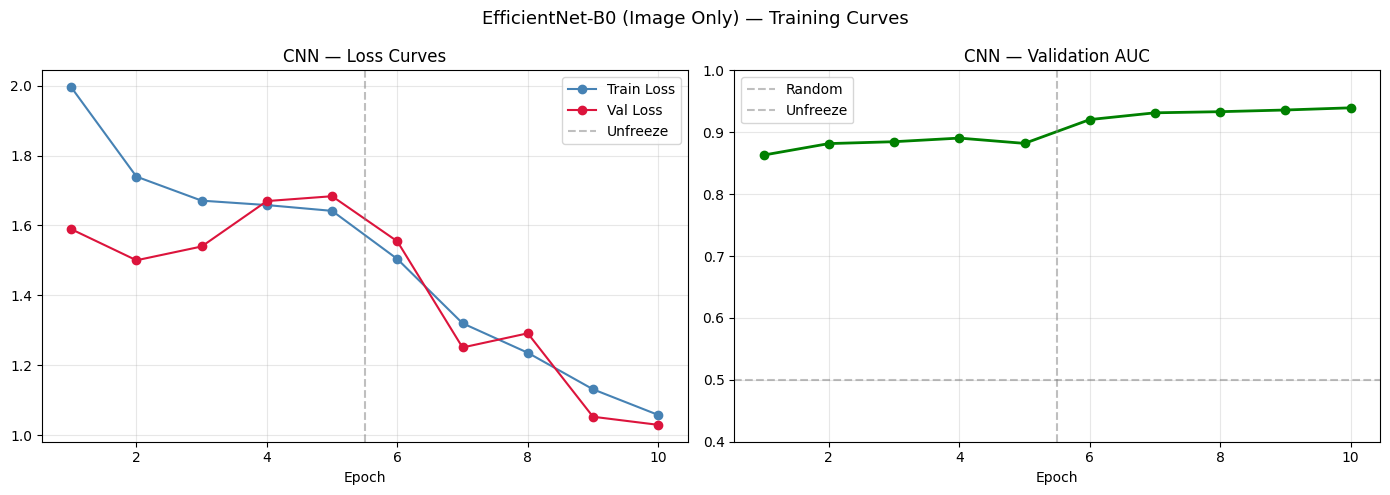

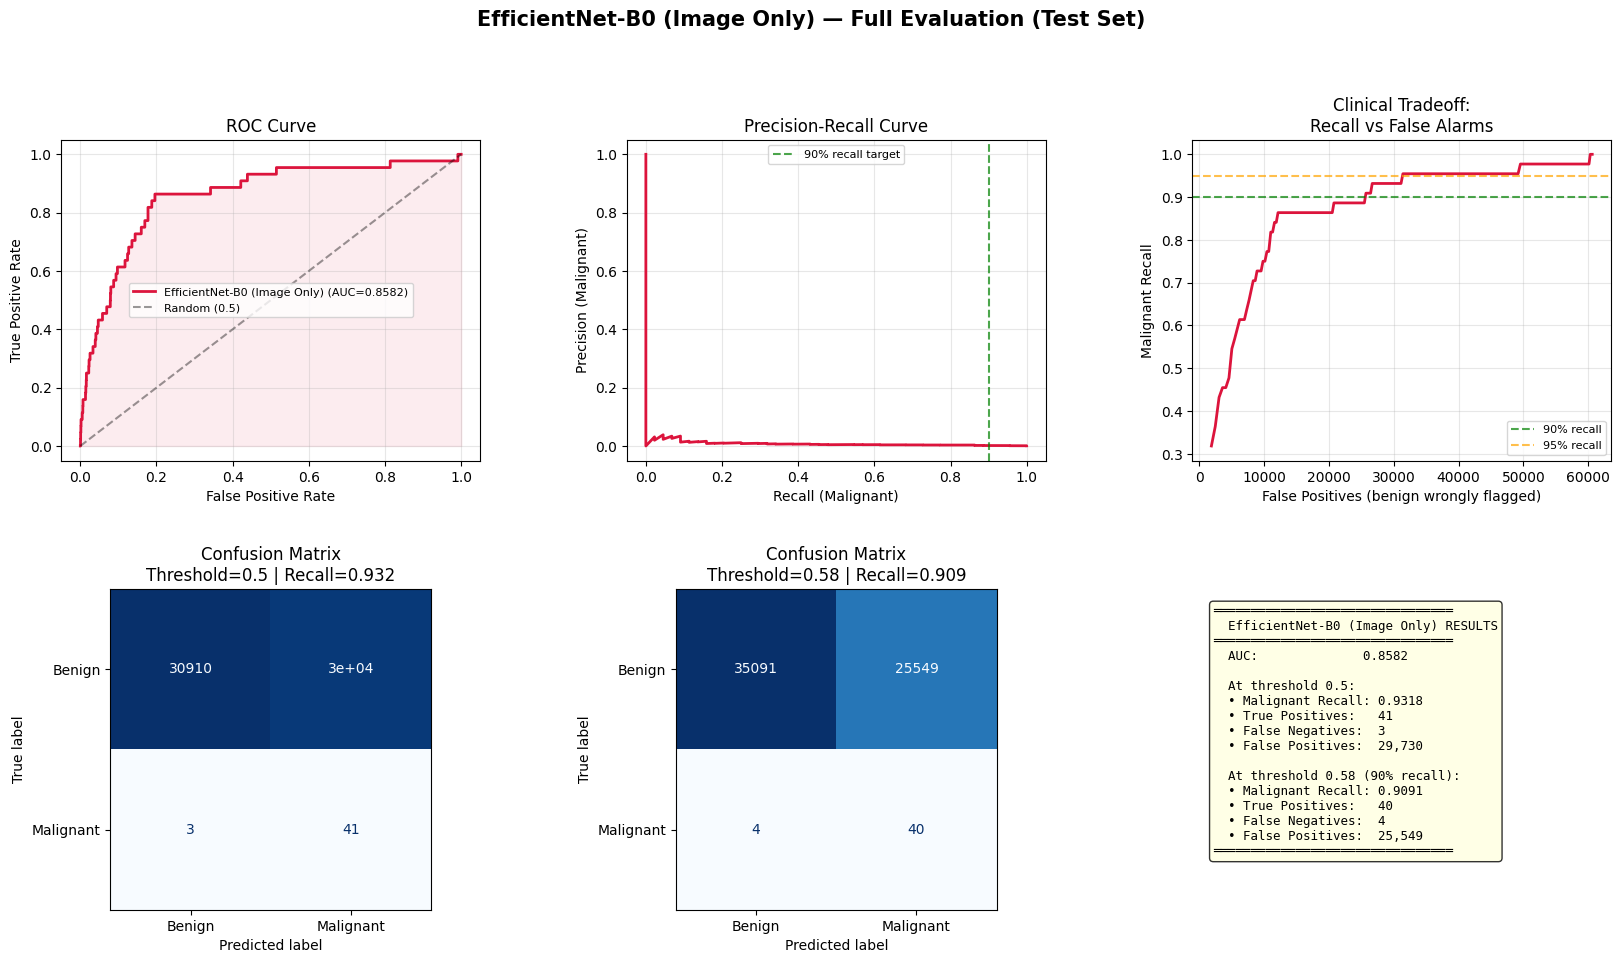


=== EfficientNet-B0 (Image Only) — Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

      Benign       1.00      0.51      0.68     60640
   Malignant       0.00      0.93      0.00        44

    accuracy                           0.51     60684
   macro avg       0.50      0.72      0.34     60684
weighted avg       1.00      0.51      0.67     60684



In [43]:
# MODEL 2: CNN ON IMAGES ONLY (EfficientNet-B0)

img_dir = "train-image/image"
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

#  Dataset
class ImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(
            os.path.join(self.img_dir, f"{row['isic_id']}.jpg")).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['label']), dtype=torch.float32)

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Oversample malignant in train only
mal_tr  = train_data[train_data['label']==1]
ben_tr  = train_data[train_data['label']==0].sample(5000, random_state=42)
train_bal = pd.concat([
    ben_tr, mal_tr,
    mal_tr.sample(len(mal_tr)*9, replace=True, random_state=42)
]).reset_index(drop=True)

cnn_train_loader = DataLoader(ImageDataset(train_bal,  img_dir, train_tf),
                               batch_size=32, shuffle=True,  num_workers=2)
cnn_val_loader   = DataLoader(ImageDataset(val_data,   img_dir, eval_tf),
                               batch_size=32, shuffle=False, num_workers=2)
cnn_test_loader  = DataLoader(ImageDataset(test_data,  img_dir, eval_tf),
                               batch_size=32, shuffle=False, num_workers=2)

# Model
cnn_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
for param in cnn_model.parameters(): param.requires_grad = False
cnn_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(cnn_model.classifier[1].in_features, 1)
)
cnn_model = cnn_model.to(device)

pos_w     = torch.tensor([len(ben_tr)/len(mal_tr)]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
optimizer = torch.optim.Adam(cnn_model.classifier.parameters(), lr=1e-3)

# Training helpers
def run_epoch(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss, probs_all, labels_all = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            lbls = lbls.unsqueeze(1).to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item()
            probs_all.extend(torch.sigmoid(out).cpu().detach().numpy().flatten())
            labels_all.extend(lbls.cpu().numpy().flatten())
    epoch_auc = roc_auc_score(labels_all, probs_all)
    return total_loss/len(loader), epoch_auc

# Phase 1: frozen backbone (5 epochs)
print("\n=== CNN Phase 1: Frozen backbone ===")
cnn_train_losses, cnn_val_losses, cnn_val_aucs = [], [], []

for epoch in range(5):
    tl, _  = run_epoch(cnn_model, cnn_train_loader, optimizer, criterion, train=True)
    vl, va = run_epoch(cnn_model, cnn_val_loader,   optimizer, criterion, train=False)
    cnn_train_losses.append(tl); cnn_val_losses.append(vl); cnn_val_aucs.append(va)
    print(f"Epoch {epoch+1}/5 | Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | Val AUC: {va:.4f}")

# Phase 2: unfreeze all (5 epochs)
print("\n=== CNN Phase 2: Full fine-tuning ===")
for param in cnn_model.parameters(): param.requires_grad = True
optimizer2 = torch.optim.Adam(cnn_model.parameters(), lr=1e-5)

for epoch in range(5):
    tl, _  = run_epoch(cnn_model, cnn_train_loader, optimizer2, criterion, train=True)
    vl, va = run_epoch(cnn_model, cnn_val_loader,   optimizer2, criterion, train=False)
    cnn_train_losses.append(tl); cnn_val_losses.append(vl); cnn_val_aucs.append(va)
    print(f"Epoch {epoch+6}/10 | Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | Val AUC: {va:.4f}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = list(range(1, 11))
axes[0].plot(ep, cnn_train_losses,'o-',color='steelblue',label='Train Loss')
axes[0].plot(ep, cnn_val_losses,  'o-',color='crimson',  label='Val Loss')
axes[0].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze')
axes[0].set_title('CNN — Loss Curves'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, cnn_val_aucs,'o-',color='green',linewidth=2)
axes[1].axhline(y=0.5,color='gray',linestyle='--',alpha=0.5,label='Random')
axes[1].axvline(x=5.5,color='gray',linestyle='--',alpha=0.5,label='Unfreeze')
axes[1].set_title('CNN — Validation AUC'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.4, 1.0); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('EfficientNet-B0 (Image Only) — Training Curves', fontsize=13)
plt.tight_layout(); plt.show()

# Evaluate on TEST set
cnn_model.eval()
cnn_probs_test, cnn_labels_test = [], []
with torch.no_grad():
    for imgs, lbls in cnn_test_loader:
        out = cnn_model(imgs.to(device))
        cnn_probs_test.extend(torch.sigmoid(out).cpu().numpy().flatten())
        cnn_labels_test.extend(lbls.numpy().flatten())

cnn_probs_test  = np.array(cnn_probs_test)
cnn_labels_test = np.array(cnn_labels_test)

cnn_auc, cnn_fpr, cnn_tpr = full_evaluation(
    cnn_labels_test, cnn_probs_test,
    model_name='EfficientNet-B0 (Image Only)',
    color='crimson'
)

## 3. Model 2: EfficientNet-B0: Image Only CNN



=== Combined Phase 1: Frozen backbone ===
Epoch 1/5 | Train: 1.4056 | Val: 1.0583 | AUC: 0.9300
Epoch 2/5 | Train: 0.9970 | Val: 0.7541 | AUC: 0.9431
Epoch 3/5 | Train: 0.9238 | Val: 0.5986 | AUC: 0.9280
Epoch 4/5 | Train: 0.8437 | Val: 0.5881 | AUC: 0.9064
Epoch 5/5 | Train: 0.7907 | Val: 0.4328 | AUC: 0.9328

=== Combined Phase 2: Full fine-tuning ===
Epoch 6/10 | Train: 0.7367 | Val: 0.4136 | AUC: 0.9350
Epoch 7/10 | Train: 0.6742 | Val: 0.4440 | AUC: 0.9360
Epoch 8/10 | Train: 0.6425 | Val: 0.4519 | AUC: 0.9308
Epoch 9/10 | Train: 0.6319 | Val: 0.4307 | AUC: 0.9368
Epoch 10/10 | Train: 0.6531 | Val: 0.4078 | AUC: 0.9378


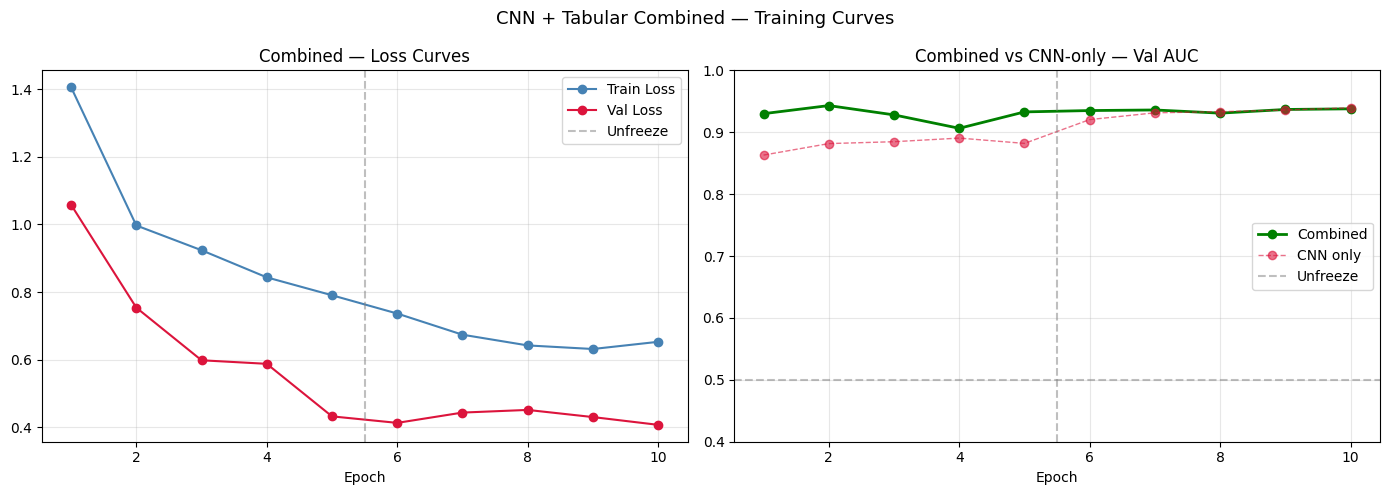

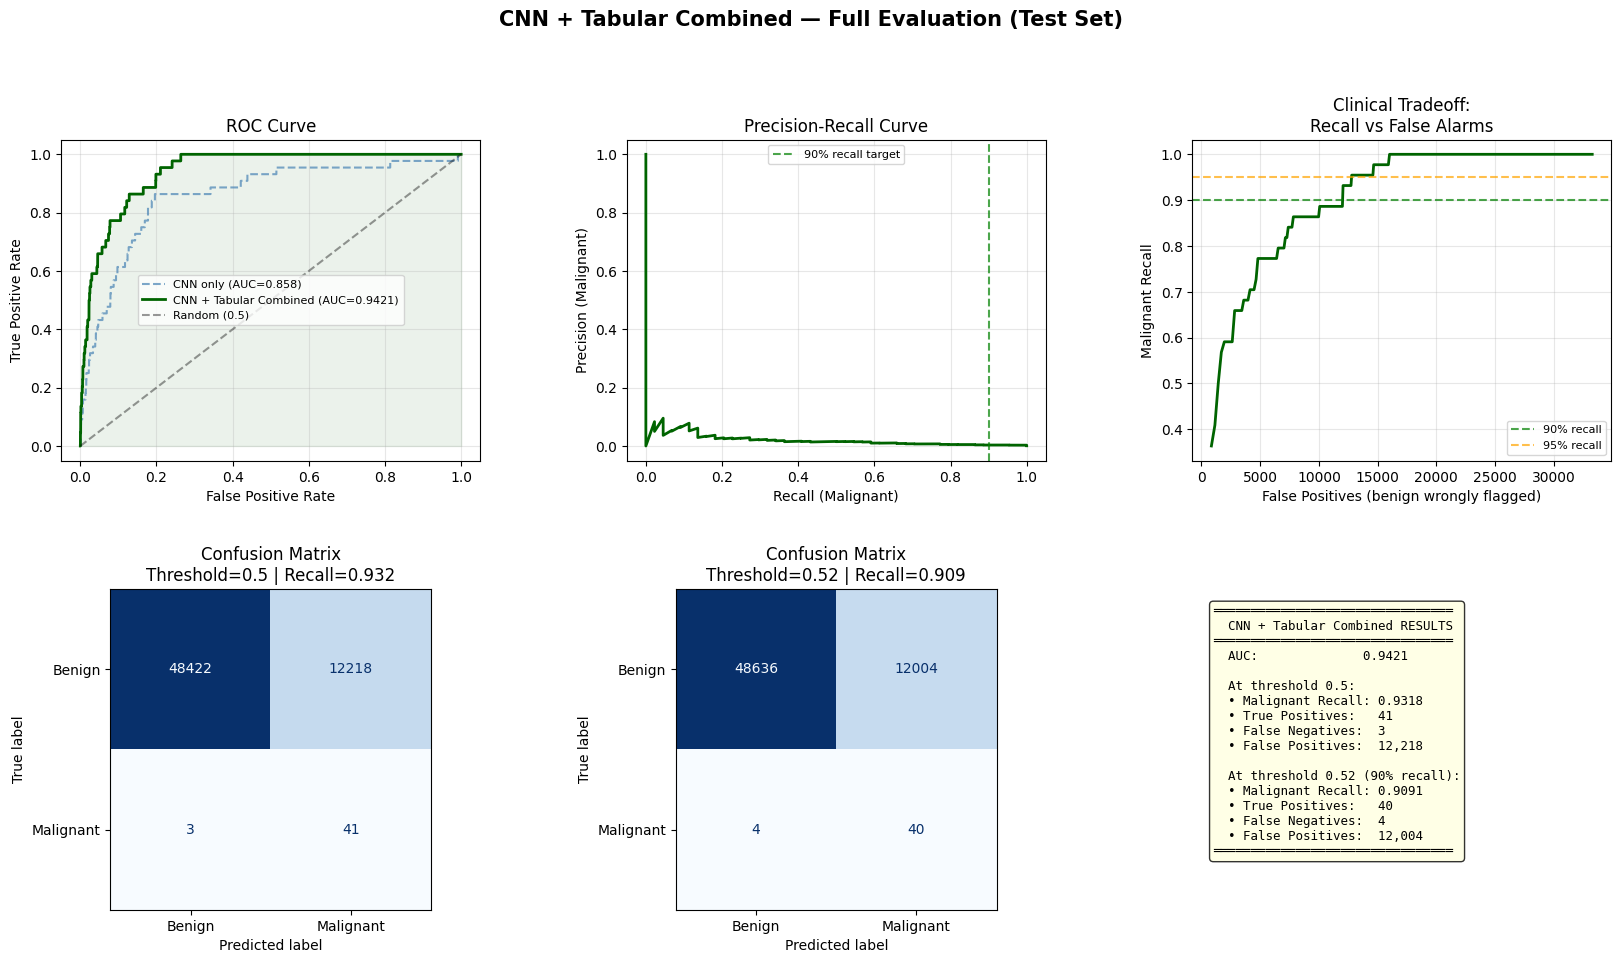


=== CNN + Tabular Combined — Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

      Benign       1.00      0.80      0.89     60640
   Malignant       0.00      0.93      0.01        44

    accuracy                           0.80     60684
   macro avg       0.50      0.87      0.45     60684
weighted avg       1.00      0.80      0.89     60684



In [44]:
# MODEL 3: CNN + TABULAR COMBINED

class CombinedDataset(Dataset):
    def __init__(self, df, img_dir, tab_features, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.tab_features = tab_features
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(
            os.path.join(self.img_dir, f"{row['isic_id']}.jpg")).convert('RGB')
        if self.transform: img = self.transform(img)
        tab = torch.tensor(row[self.tab_features].values.astype(np.float32))
        lbl = torch.tensor(int(row['label']), dtype=torch.float32)
        return img, tab, lbl

class CombinedModel(nn.Module):
    def __init__(self, n_tab):
        super().__init__()
        eff = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.img_branch = nn.Sequential(*list(eff.children())[:-1])
        self.tab_branch = nn.Sequential(
            nn.Linear(n_tab, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),   nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(1280+64, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 64),     nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, img, tab):
        i = self.img_branch(img).flatten(start_dim=1)
        t = self.tab_branch(tab)
        return self.classifier(torch.cat([i, t], dim=1))

# Scale tabular features
scaler2 = StandardScaler()
train_data_c = train_data.copy()
val_data_c   = val_data.copy()
test_data_c  = test_data.copy()

train_data_c[all_features] = scaler2.fit_transform(train_data_c[all_features].fillna(0))
val_data_c[all_features]   = scaler2.transform(val_data_c[all_features].fillna(0))
test_data_c[all_features]  = scaler2.transform(test_data_c[all_features].fillna(0))

# Oversample malignant
mal_tr2  = train_data_c[train_data_c['label']==1]
ben_tr2  = train_data_c[train_data_c['label']==0].sample(5000, random_state=42)
train_bal2 = pd.concat([
    ben_tr2, mal_tr2,
    mal_tr2.sample(len(mal_tr2)*9, replace=True, random_state=42)
]).reset_index(drop=True)

comb_train_loader = DataLoader(CombinedDataset(train_bal2,  img_dir, all_features, train_tf),
                                batch_size=32, shuffle=True,  num_workers=2)
comb_val_loader   = DataLoader(CombinedDataset(val_data_c,  img_dir, all_features, eval_tf),
                                batch_size=32, shuffle=False, num_workers=2)
comb_test_loader  = DataLoader(CombinedDataset(test_data_c, img_dir, all_features, eval_tf),
                                batch_size=32, shuffle=False, num_workers=2)

combined_model = CombinedModel(n_tab=len(all_features)).to(device)

# Freeze image branch first
for param in combined_model.img_branch.parameters(): param.requires_grad = False

pos_w2     = torch.tensor([len(ben_tr2)/len(mal_tr2)]).to(device)
criterion2 = nn.BCEWithLogitsLoss(pos_weight=pos_w2)
optimizer3 = torch.optim.Adam(
    list(combined_model.tab_branch.parameters()) +
    list(combined_model.classifier.parameters()), lr=1e-3)

def run_epoch_combined(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss, probs_all, labels_all = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, tab, lbls in loader:
            imgs = imgs.to(device); tab = tab.to(device)
            lbls = lbls.unsqueeze(1).to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs, tab)
            loss = criterion(out, lbls)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item()
            probs_all.extend(torch.sigmoid(out).cpu().detach().numpy().flatten())
            labels_all.extend(lbls.cpu().numpy().flatten())
    return total_loss/len(loader), roc_auc_score(labels_all, probs_all)

# ── Phase 1: frozen backbone ───────────────────────────────────
print("\n=== Combined Phase 1: Frozen backbone ===")
comb_train_losses, comb_val_losses, comb_val_aucs = [], [], []

for epoch in range(5):
    tl, _  = run_epoch_combined(combined_model, comb_train_loader, optimizer3, criterion2, True)
    vl, va = run_epoch_combined(combined_model, comb_val_loader,   optimizer3, criterion2, False)
    comb_train_losses.append(tl); comb_val_losses.append(vl); comb_val_aucs.append(va)
    print(f"Epoch {epoch+1}/5 | Train: {tl:.4f} | Val: {vl:.4f} | AUC: {va:.4f}")

# Phase 2: unfreeze all
print("\n=== Combined Phase 2: Full fine-tuning ===")
for param in combined_model.img_branch.parameters(): param.requires_grad = True
optimizer4 = torch.optim.Adam(combined_model.parameters(), lr=1e-5)

for epoch in range(5):
    tl, _  = run_epoch_combined(combined_model, comb_train_loader, optimizer4, criterion2, True)
    vl, va = run_epoch_combined(combined_model, comb_val_loader,   optimizer4, criterion2, False)
    comb_train_losses.append(tl); comb_val_losses.append(vl); comb_val_aucs.append(va)
    print(f"Epoch {epoch+6}/10 | Train: {tl:.4f} | Val: {vl:.4f} | AUC: {va:.4f}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = list(range(1, 11))
axes[0].plot(ep, comb_train_losses,'o-',color='steelblue',label='Train Loss')
axes[0].plot(ep, comb_val_losses,  'o-',color='crimson',  label='Val Loss')
axes[0].axvline(x=5.5,color='gray',linestyle='--',alpha=0.5,label='Unfreeze')
axes[0].set_title('Combined — Loss Curves'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, comb_val_aucs,'o-',color='green',linewidth=2,label='Combined')
axes[1].plot(ep, cnn_val_aucs, 'o-',color='crimson',linewidth=1,
             linestyle='--',alpha=0.6,label='CNN only')
axes[1].axhline(y=0.5,color='gray',linestyle='--',alpha=0.5)
axes[1].axvline(x=5.5,color='gray',linestyle='--',alpha=0.5,label='Unfreeze')
axes[1].set_title('Combined vs CNN-only — Val AUC'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.4,1.0); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('CNN + Tabular Combined — Training Curves', fontsize=13)
plt.tight_layout(); plt.show()

# Evaluate on TEST set
combined_model.eval()
comb_probs_test, comb_labels_test = [], []
with torch.no_grad():
    for imgs, tab, lbls in comb_test_loader:
        out = combined_model(imgs.to(device), tab.to(device))
        comb_probs_test.extend(torch.sigmoid(out).cpu().numpy().flatten())
        comb_labels_test.extend(lbls.numpy().flatten())

comb_probs_test  = np.array(comb_probs_test)
comb_labels_test = np.array(comb_labels_test)

comb_auc, comb_fpr, comb_tpr = full_evaluation(
    comb_labels_test, comb_probs_test,
    model_name='CNN + Tabular Combined',
    color='darkgreen',
    cnn_fpr=cnn_fpr, cnn_tpr=cnn_tpr   # overlays CNN-only on this plot
)

## 5. Final Model Comparison


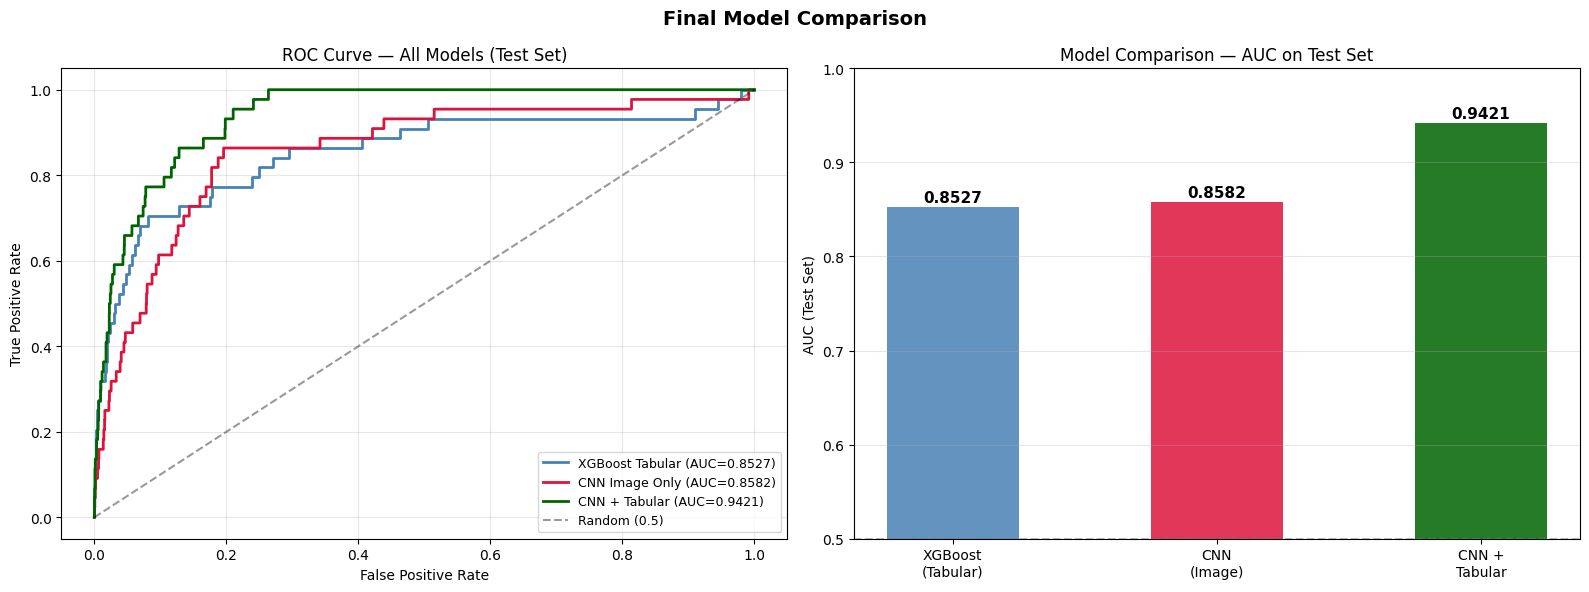


════════════════════════════════════════════════════════════
           FINAL MODEL COMPARISON — TEST SET
════════════════════════════════════════════════════════════
Model                          AUC   Recall@0.5        Modality
────────────────────────────────────────────────────────────
XGBoost (Tabular)           0.8527    see plots    Tabular only
CNN (Image)                 0.8582    see plots      Image only
CNN + Tabular               0.9421    see plots Image + Tabular
════════════════════════════════════════════════════════════
Best model: CNN + Tabular Combined
AUC improvement over CNN-only: +0.0839
AUC improvement over XGBoost:  +0.0894


In [45]:
# FINAL COMPARISON — all three models on the same plot

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC comparison
for (name, f, t, c, ls) in [
    ('XGBoost Tabular',    xgb_fpr,  xgb_tpr,  'steelblue', '-'),
    ('CNN Image Only',     cnn_fpr,  cnn_tpr,  'crimson',   '-'),
    ('CNN + Tabular',      comb_fpr, comb_tpr, 'darkgreen', '-'),
]:
    a = auc(f, t)
    axes[0].plot(f, t, color=c, lw=2, linestyle=ls, label=f'{name} (AUC={a:.4f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Random (0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — All Models (Test Set)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# AUC bar chart
model_names = ['XGBoost\n(Tabular)', 'CNN\n(Image)', 'CNN +\nTabular']
aucs        = [xgb_auc, cnn_auc, comb_auc]
colors_bar  = ['steelblue', 'crimson', 'darkgreen']

bars = axes[1].bar(model_names, aucs, color=colors_bar, alpha=0.85, width=0.5)
axes[1].set_ylim(0.5, 1.0)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
axes[1].set_ylabel('AUC (Test Set)')
axes[1].set_title('Model Comparison — AUC on Test Set')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Final Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "═"*60)
print("           FINAL MODEL COMPARISON — TEST SET")
print("═"*60)
print(f"{'Model':<25} {'AUC':>8} {'Recall@0.5':>12} {'Modality':>15}")
print("─"*60)

for name, probs, labels, col in [
    ('XGBoost (Tabular)',    xgb_auc,  None, 'Tabular only'),
    ('CNN (Image)',          cnn_auc,  None, 'Image only'),
    ('CNN + Tabular',        comb_auc, None, 'Image + Tabular'),
]:
    print(f"{name:<25} {probs:>8.4f} {'see plots':>12} {col:>15}")

print("═"*60)
print("Best model: CNN + Tabular Combined")
print(f"AUC improvement over CNN-only: {comb_auc - cnn_auc:+.4f}")
print(f"AUC improvement over XGBoost:  {comb_auc - xgb_auc:+.4f}")